# Bloch Neural ODE / PINN Training Pipeline

This notebook combines the project code into a single executable pipeline: simulator, dataset creation, model definitions (Neural ODE RK4, GRU, PINN), training loops, and inference utilities. Code is included largely verbatim from the original files with comments preserved.

Usage notes:
- Run cells in order.
- You may need to install dependencies: `torch`, `numpy`, `matplotlib`, `tqdm`, and optionally `torchdiffeq` for the adaptive ODE model.

In [117]:
 # Setup Code
import sys, os
from pathlib import Path
ROOT = Path('.').resolve()  # notebook placed at repo root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

Project root: C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project


## Simulator Code adapted from ____

In [118]:
# Bloch equation simulator for MRI applications, adapted
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Optional, Callable
import json


@dataclass # class that just holds data
class Isochromat: # spin packet: group of spins that are @ same loc and experience same B field.
    """Represents a single isochromat (spin packet) with position and magnetization"""
    M: np.ndarray  # Magnetization vector [Mx, My, Mz] (current magnetization vector of packet)
    pos: np.ndarray  # Position [x, y, z] (spatial position of packet, used in gradient sim.)
    dB0: float = 0.0  # Field offset (field inhomogeneity. irl, B0 isn't uniform & dB0 is small constant 
                      # offset. primary cause of signal decay.)
    T1: float = np.inf  # Longitudinal relaxation time (how quickly component along main field M_z recovers to o.g. M_0
                        # small T_1 => fast recovery)
    T2: float = np.inf  # Transverse relaxation time (how quickly M_x and M_y decay to 0 b/c of random microscopic spin
                        # interactions.)
    M0: float = 1.0  # Equilibrium magnetization (fully relaxed magnetization vector in +z axis. )


class BlochSimulator:
    
    def __init__(self, gamma: float = 1.0, B0: float = 2.0):
        """
            gamma: Gyromagnetic ratio (default normalized to 1) (omega = gamma * B)
            B0: Main magnetic field strength
        """
        self.gamma = gamma 
        self.B0 = B0 # strength of main static B field
        self.isochromats: List[Isochromat] = [] # list of all spin packets
        self.time = 0.0 # current time ig
        self.history = [] # snapshot of system state at every time step
        
        # Field parameters
        self.B1 = 0.0  # RF field amplitude
        self.B1_freq = 0.0  # RF frequency
        self.phi1 = 0.0  # RF phase
        self.Gx = 0.0  # X gradient
        self.Gy = 0.0  # Y gradient
        
        # Pulse parameters
        self.RF_active = False
        self.RF_time_left = 0.0
        self.RF_area_left = 0.0
        self.RF_func: Optional[Callable] = None
        
    def add_isochromat(self, M: np.ndarray, pos: np.ndarray = np.array([0, 0, 0]),
                       dB0: float = 0.0, T1: float = np.inf, T2: float = np.inf):
        # Add an isochromat to the simulation
        iso = Isochromat(M=M.copy(), pos=pos.copy(), dB0=dB0, T1=T1, T2=T2)
        self.isochromats.append(iso)
        
    def setup_single_spin(self):
        # Setup a single perfect spin at origin w/o relaxation equilibrium 
        self.isochromats.clear()
        self.add_isochromat(np.array([0, 0, 1]))
        
    def setup_inhomogeneous(self, n_spins: int = 9, spread: float = 0.3):
        # Setup multiple spins with field inhomogeneity. Multiple spins @ same location but diff. dBO values. Simulate T2 decay
        # where diff spins precess @ diff speeds and fan out in xy plane (causing signal decay).
        self.isochromats.clear()
        for i in range(n_spins):
            dB0 = (i - (n_spins-1)/2) / (n_spins/6) * spread
            self.add_isochromat(np.array([0, 0, 1]), dB0=dB0)
            
    def setup_spatial_line(self, n_spins: int = 21, spacing: float = 0.4):
        # Setup spins along a line (x-axis) for gradient testing. Show if G_x (x gradient) works.
        self.isochromats.clear()
        for i in range(n_spins):
            x_pos = (i - (n_spins-1)/2) * spacing
            self.add_isochromat(
                np.array([0, 0, 1]), 
                pos=np.array([x_pos, 0, 0])
            )
            
    def setup_relaxation(self, T1: float = 5.0, T2: float = 3.0):
        # Setup a single spin with relaxation (finite T1, T2 values). 
        self.isochromats.clear()
        self.add_isochromat(np.array([0, 0, 1]), T1=T1, T2=T2)
        
    def RF_pulse_rect(self, angle: float, phase: float, B1_amplitude: float = 4.0):
        """
        Apply rectangular RF pulse

            angle: Flip angle in radians
            phase: RF phase in radians
            B1_amplitude: RF field strength
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase
        duration = angle / (self.gamma * B1_amplitude)
        
        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = self._RF_const # which function step method shoudl call to get B1 field value @ some time.
        
    def RF_pulse_sinc(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                      n_lobes: int = 4):
        # a sinc-shaped RF pulse
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase
        
        # Sinc pulse is longer to maintain same area
        sinc_correction = 0.22570583339507  # Si(2π)/(2π) for 4-lobe sinc
        duration = angle / (self.gamma * B1_amplitude * sinc_correction)
        
        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_sinc(t, duration, n_lobes)

    # RF_const and RF_sinc actually calculate B1 vector at time t.  
    def _RF_const(self, t: float) -> Tuple[np.ndarray, float]:
        # Constant (rectangular) RF pulse shape
        phase = self.B1_freq * t - self.phi1
        B1_vec = np.array([
            self.B1 * np.cos(phase),
            -self.B1 * np.sin(phase),
            0.0
        ])
        return B1_vec, self.B1
    
    def _RF_sinc(self, t: float, duration: float, n_lobes: int) -> Tuple[np.ndarray, float]:
        # Sinc RF pulse shape
        phase = self.B1_freq * t - self.phi1
        sinc_arg = n_lobes * np.pi * (t/duration - 0.5)
        
        if abs(sinc_arg) > 0.01:
            envelope = self.B1 * np.sin(sinc_arg) / sinc_arg
        else:
            envelope = self.B1
            
        B1_vec = np.array([
            envelope * np.cos(phase),
            -envelope * np.sin(phase),
            0.0
        ])
        return B1_vec, envelope
    
    import numpy as np

    # ----------------------- Helpers (inside the class) -----------------------

    def _duration_from_envelope_avg(self, angle, B1_peak, env_of_tau, n=4096):
        """
        Numerically compute the duration that yields the requested flip angle.

        We assume an envelope defined on tau in [0,1] with peak 1.0:
            B1(t) = B1_peak * env_of_tau(t / duration)
        => area = ∫ B1 dt = B1_peak * duration * ∫_0^1 env(τ) dτ
        Flip angle: angle = gamma * area

        So: duration = angle / (gamma * B1_peak * avg_env),
            where avg_env = ∫_0^1 env(τ) dτ
        """
        tau = np.linspace(0.0, 1.0, n, endpoint=False) + 0.5 / n
        env_vals = env_of_tau(tau)
        avg_env = np.trapz(env_vals, tau)  # integral over [0,1]
        avg_env = float(max(avg_env, 1e-12))  # guard
        return angle / (self.gamma * B1_peak * avg_env)

    # -------------------- 1) Gaussian pulse (RF_pulse_gaussian) --------------------

    def RF_pulse_gaussian(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                        sigma_frac: float = 0.20):
        """
        Apply a Gaussian-envelope RF pulse with flip-angle normalization.

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: peak B1 (envelope peak = 1.0 -> peak field = B1_amplitude)
        sigma_frac: controls width of the Gaussian relative to duration
                    (σ in units of half-duration; 0.2 is a common smooth choice)
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        # envelope on τ ∈ [0,1], centered at 0.5
        def env_of_tau(tau):
            # convert sigma_frac (fraction of half-duration) to σ on τ-domain
            # half-duration in τ is 0.5, so σ_τ = sigma_frac / 0.5
            sigma_tau = sigma_frac / 0.5
            return np.exp(-0.5 * ((tau - 0.5) / sigma_tau) ** 2)

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_gaussian(t, duration, sigma_frac)

    def _RF_gaussian(self, t: float, duration: float, sigma_frac: float):
        """Return (B1_vec, envelope) for Gaussian envelope at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        sigma_tau = sigma_frac / 0.5
        env = float(np.exp(-0.5 * ((tau - 0.5) / sigma_tau) ** 2))

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env

    # --------------- 2) Hamming-windowed sinc (RF_pulse_windowed_sinc) ---------------

    def RF_pulse_windowed_sinc(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                            n_lobes: int = 4):
        """
        Apply a Hamming-windowed sinc RF pulse (cleaner spectrum than plain sinc).

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: peak B1 (after windowing; peak env is normalized to 1)
        n_lobes: number of lobes on each side of the center
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        # Continuous-time Hamming window on τ ∈ [0,1]
        def window_hamming(tau):
            return 0.54 - 0.46 * np.cos(2 * np.pi * tau)

        def env_of_tau(tau):
            # Map τ∈[0,1] to x∈[-n_lobes, n_lobes]
            x = (tau - 0.5) * 2.0 * n_lobes
            sinc = np.sinc(x)  # np.sinc uses sin(πx)/(πx); OK up to scale
            env = sinc * window_hamming(tau)
            # normalize to peak 1.0 so B1_amplitude is actual peak
            peak = np.max(np.abs(env))
            return env / (peak + 1e-12)

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_windowed_sinc(t, duration, n_lobes)

    def _RF_windowed_sinc(self, t: float, duration: float, n_lobes: int):
        """Return (B1_vec, envelope) for Hamming-windowed sinc at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        x = (tau - 0.5) * 2.0 * n_lobes
        sinc = np.sinc(x)
        window = 0.54 - 0.46 * np.cos(2 * np.pi * tau)
        env = sinc * window
        env /= (np.max([abs(env), 1e-12]))  # tiny guard if called at boundaries

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env

    # ------------------ 3) Trapezoidal (ramps) (RF_pulse_trapezoid) ------------------

    def RF_pulse_trapezoid(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                        ramp_frac: float = 0.10):
        """
        Apply a trapezoidal RF pulse with linear rise/fall ramps.

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: plateau peak
        ramp_frac: fraction of the duration used for each ramp (0–0.5)
        """
        ramp_frac = float(np.clip(ramp_frac, 0.0, 0.49))
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        def env_of_tau(tau):
            # piecewise linear: rise -> flat -> fall on τ∈[0,1]
            r = ramp_frac
            env = np.empty_like(tau)
            # rise
            rise = tau < r
            env[rise] = tau[rise] / max(r, 1e-12)
            # flat
            flat = (tau >= r) & (tau <= 1.0 - r)
            env[flat] = 1.0
            # fall
            fall = tau > 1.0 - r
            env[fall] = (1.0 - tau[fall]) / max(r, 1e-12)
            return env

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_trapezoid(t, duration, ramp_frac)

    def _RF_trapezoid(self, t: float, duration: float, ramp_frac: float):
        """Return (B1_vec, envelope) for a trapezoid at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        r = ramp_frac
        if tau < r:
            env = tau / max(r, 1e-12)
        elif tau <= 1.0 - r:
            env = 1.0
        else:
            env = (1.0 - tau) / max(r, 1e-12)

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env



    def random_fourier_pulse(T: int, dt: float, A: float, n_terms: int = 5):
        """
        Generate a random composite pulse as a sum of sinusoids.

        Parameters
        ----------
        T : int
            Number of samples.
        dt : float
            Time step (seconds).
        A : float
            Overall amplitude scaling.
        n_terms : int
            Number of random harmonic components to sum.

        Returns
        -------
        np.ndarray
            Random, smooth RF envelope normalized to amplitude A.
        """
        t = np.arange(T) * dt
        y = np.zeros_like(t)
        for _ in range(n_terms):
            f = np.random.uniform(100, 5000)  # random frequency in Hz
            phi = np.random.uniform(0, 2 * np.pi)
            y += np.sin(2 * np.pi * f * t + phi)
        y /= np.max(np.abs(y)) + 1e-8
        return (A * y).astype(np.float32)



    def apply_gradient(self, phase_diff: float, direction_angle: float = 0.0):
        """Apply gradient pulse"""
        grad_scale = 11  # From o.g. code
        duration = 1.0  # seconds
        area = phase_diff * grad_scale / self.gamma
        
        self.Gx = np.cos(direction_angle) * area / duration
        self.Gy = np.sin(direction_angle) * area / duration
        
    def step(self, dt: float):
        """
        Evolve the system by one time step using Bloch equations

            dt: Time step in seconds
        """
        self.time += dt
        
        # Get RF field
        if self.RF_active and self.RF_time_left > 0: # check if RF is on and time remaining
            B1_vec, envelope = self.RF_func(self.time) # get B1 vector
            dArea = dt * self.gamma * envelope
            
            if self.RF_time_left < dt:
                # End of pulse (adjust to match target angle)
                B1_vec *= self.RF_area_left / dArea
                self.RF_active = False
                self.RF_time_left = 0
                self.B1 = 0
            else:
                self.RF_area_left -= dArea
                self.RF_time_left -= dt
        else: # no B1 vec if no RF
            B1_vec = np.array([0, 0, 0])
            self.RF_active = False
            
        # Update each isochromat
        for iso in self.isochromats:
            # Total field including gradients and offsets. total B field each iso feels at this instant.
            grad_scale = 11  # From o.g. code
            detuning = iso.dB0 + (self.Gx * iso.pos[0] + self.Gy * iso.pos[1]) / grad_scale
            # z field detuning is sum of spin's personal offset and gradient fields.  multiplications mean "if G_x grad on, 
            # field depends on x_position)"
            B_total = B1_vec + np.array([0, 0, self.B0 + detuning])
            
            # Precession (M x B term) (Rotation due to B field)
            B_mag = np.linalg.norm(B_total)
            if B_mag > 1e-10:
                rotation_angle = -B_mag * dt * self.gamma
                rotation_axis = B_total / B_mag
                
                # Rodrigues' rotation formula
                K = np.array([
                    [0, -rotation_axis[2], rotation_axis[1]],
                    [rotation_axis[2], 0, -rotation_axis[0]],
                    [-rotation_axis[1], rotation_axis[0], 0]
                ])
                R = np.eye(3) + np.sin(rotation_angle) * K + \
                    (1 - np.cos(rotation_angle)) * K @ K
                iso.M = R @ iso.M # isochromat's magnetizatoin vector updated by matrix-multiplying it by rotation
                # matrix R to precess vector.
            
            # Relaxation (T1, T2 terms)
            if np.isfinite(iso.T1) or np.isfinite(iso.T2):
                f1 = np.exp(-dt / iso.T1) if np.isfinite(iso.T1) else 1.0 # exponential decay factor for M_z in time dt
                f2 = np.exp(-dt / iso.T2) if np.isfinite(iso.T2) else 1.0 # exponential decay factor for M_x and M_y in time dt.
                
                iso.M[0] *= f2 # Mx decays toward 0
                iso.M[1] *= f2 # My decays toward 0
                iso.M[2] = iso.M[2] * f1 + (1 - f1) * iso.M0 # analytic solution for T1 relaxation. M_z decays toward 0 w/
                # f1 and (at teh same time) grows back towards M0 (equil)
        
        # Store history
        self._record_state() # append state of all isochromats to self.history
        
    def _record_state(self):
        """Record current state for history"""
        state = {
            'time': self.time,
            'magnetization': np.array([iso.M.copy() for iso in self.isochromats]),
            'B1': self.B1,
            'RF_active': self.RF_active
        }
        self.history.append(state)
        
    def get_total_magnetization(self) -> np.ndarray:
        # Get total magnetization vector
        return np.sum([iso.M for iso in self.isochromats], axis=0)
    
    def get_transverse_magnetization(self) -> float:
        # Get magnitude of transverse magnetization
        M_total = self.get_total_magnetization()
        return np.sqrt(M_total[0]**2 + M_total[1]**2)
    
    def simulate_sequence(self, duration: float, dt: float = 0.01):
        """
        Run simulation for specified duration

            duration: Total simulation time
            dt: Time step
        """
        steps = int(duration / dt)
        for _ in range(steps):
            self.step(dt)
            
    def reset(self):
        # Reset simulation
        self.time = 0.0
        self.history.clear()
        for iso in self.isochromats:
            iso.M = np.array([0, 0, iso.M0])


In [119]:
class BlochVisualizer:
    # Visualization for Bloch simulation
    
    @staticmethod
    def plot_magnetization_trajectory(simulator: BlochSimulator, figsize=(12, 4)):
        # Plot Mx, My, Mz over time. Calculates total magnetizaiotn by summing M vectors of all isochromats
        # at each time step.
        if not simulator.history:
            print("No simulation data to plot")
            return
            
        times = [state['time'] for state in simulator.history]
        M_total = np.array([
            np.sum(state['magnetization'], axis=0) / len(simulator.isochromats)
            for state in simulator.history
        ])
        
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        axes[0].plot(times, M_total[:, 0], 'r-', linewidth=2)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Mx')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_title('X Magnetization')
        
        axes[1].plot(times, M_total[:, 1], 'g-', linewidth=2)
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('My')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_title('Y Magnetization')
        
        axes[2].plot(times, M_total[:, 2], 'b-', linewidth=2)
        axes[2].set_xlabel('Time (s)')
        axes[2].set_ylabel('Mz')
        axes[2].grid(True, alpha=0.3)
        axes[2].set_title('Z Magnetization')
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_bloch_sphere(simulator: BlochSimulator, frame_idx: int = -1):
        # Plot magnetization vectors on Bloch sphere. Default picks last time step. Draw M vector for each isochromat.
        # use for dephasing visual. (run setup_inhomo and vectors start aligned and then fan out across xy plane)
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Draw sphere
        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x = np.outer(np.cos(u), np.sin(v))
        y = np.outer(np.sin(u), np.sin(v))
        z = np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_surface(x, y, z, alpha=0.1, color='lightblue')
        
        # Draw axes
        ax.plot([0, 1.3], [0, 0], [0, 0], 'k-', linewidth=2, alpha=0.3)
        ax.plot([0, 0], [0, 1.3], [0, 0], 'k-', linewidth=2, alpha=0.3)
        ax.plot([0, 0], [0, 0], [0, 1.3], 'k-', linewidth=2, alpha=0.3)
        ax.text(1.4, 0, 0, 'X', fontsize=14)
        ax.text(0, 1.4, 0, 'Y', fontsize=14)
        ax.text(0, 0, 1.4, 'Z', fontsize=14)
        
        # Plot magnetization vectors
        if simulator.history:
            state = simulator.history[frame_idx]
            for M in state['magnetization']:
                ax.quiver(0, 0, 0, M[0], M[1], M[2],
                         arrow_length_ratio=0.1, linewidth=2, color='red')
        
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.set_zlim([-1.2, 1.2])
        ax.set_xlabel('Mx')
        ax.set_ylabel('My')
        ax.set_zlabel('Mz')
        ax.set_title(f'Bloch Sphere at t={simulator.history[frame_idx]["time"]:.2f}s')
        
        return fig
    
    @staticmethod
    def plot_fid_spectrum(simulator: BlochSimulator):
        # Plot FID signal and its spectrum. simulates what MRI/NMR scanner actually measures.
        if not simulator.history:
            print("No simulation data to plot")
            return
            
        times = np.array([state['time'] for state in simulator.history])
        M_total = np.array([
            np.sum(state['magnetization'], axis=0)
            for state in simulator.history
        ])
        
        # Complex transverse magnetization (FID)
        signal = M_total[:, 0] + 1j * M_total[:, 1] # scanner's reciever coil picks up oscillating transverse xy magnetization
        # represnted as complex number. time domain signal called free induction decay.
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Time domain (real, im, and mag of signal that decays)
        axes[0].plot(times, signal.real, 'b-', label='Real', linewidth=2)
        axes[0].plot(times, signal.imag, 'r-', label='Imaginary', linewidth=2)
        axes[0].plot(times, np.abs(signal), 'k--', label='Magnitude', linewidth=2)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Signal')
        axes[0].set_title('FID Signal')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Frequency domain (spectrum)
        dt = times[1] - times[0] if len(times) > 1 else 0.01
        spectrum = np.fft.fftshift(np.fft.fft(signal)) # calculates FFT of FID. time to frequency domain.
        freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), dt)) # 0 freq at center
        
        axes[1].plot(freqs, np.abs(spectrum), 'b-', linewidth=2)
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('Magnitude')
        axes[1].set_title('Spectrum')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlim([freqs[0], freqs[-1]])
        
        plt.tight_layout()
        return fig

## BlochSim Tester

Quick visual / functional tests for the `BlochSimulator` — adapted from `tests/blochsim_tester.py`. Run these to sanity-check the simulator before dataset generation or training.

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- shared helper ----------
def plot_trajectory3d(sim, title=""):
    M = np.array([np.sum(s["magnetization"], axis=0) for s in sim.history])  # (T,3)
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)

    # sphere surface (reference)
    u = np.linspace(0, 2*np.pi, 72)
    v = np.linspace(0, np.pi, 36)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, alpha=0.12, edgecolor="none")

    ax.plot(M[:, 0], M[:, 1], M[:, 2], linewidth=2)
    ax.scatter(M[0, 0], M[0, 1], M[0, 2], s=60, c="g", label="start")
    ax.scatter(M[-1, 0], M[-1, 1], M[-1, 2], s=60, c="r", label="end")
    ax.legend()
    ax.set_xlabel("Mx"); ax.set_ylabel("My"); ax.set_zlabel("Mz")
    lim = 1.2
    ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
    ax.view_init(elev=25, azim=35)
    return fig

# ---------- each case returns a configured-and-run simulator ----------
def case_free_precession():
    """Single spin; precession around +z with no relaxation."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_single_spin()
    sim.isochromats[0].M = np.array([1.0, 0.0, 0.0])  # start in xy-plane
    sim.simulate_sequence(duration=5.0, dt=0.001)
    return sim, "Free precession (B0 only)"

def case_90_then_free():
    """90° hard pulse tips M to xy; observe post-pulse precession."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_single_spin()
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=4.0)
    sim.simulate_sequence(duration=3.0, dt=0.0005)
    return sim, "90° pulse → free precession"

def case_relaxation_only():
    """No B0; watch pure T1 recovery and T2 decay toward equilibrium."""
    sim = BlochSimulator(gamma=1.0, B0=0.0)
    sim.isochromats.clear()
    sim.add_isochromat(M=np.array([1.0, 0.0, 0.0]), T1=7.0, T2=1.0)
    sim.simulate_sequence(duration=8.0, dt=0.005)
    return sim, "Relaxation only (T1/T2)"

def case_relaxation_plus_precession():
    """B0 ≠ 0; spiral back to +z while precessing."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.isochromats.clear()
    sim.add_isochromat(M=np.array([1.0, 0.0, 0.0]), T1=9.0, T2=2.0)
    sim.simulate_sequence(duration=10.0, dt=0.005)
    return sim, "Relaxation + precession"

def case_inhomogeneous_dephasing(n=15, spread=0.5):
    """Multiple spins with different dB0; transverse dephasing (T2*)."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_inhomogeneous(n_spins=n, spread=spread)
    # tip all into xy to see dephasing clearly
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=5.0)
    sim.simulate_sequence(duration=2.0, dt=0.0005)
    return sim, "Inhomogeneous dephasing (T2*)"

def case_gradient_dephase_rephase():
    """
    Simple 'gradient echo' style: turn on Gx briefly to dephase, then flip sign to rephase.
    NOTE: your apply_gradient sets a steady gradient; we emulate finite pulses by setting Gx,
    simulating, then zeroing / negating it.
    """
    sim = BlochSimulator(gamma=1.0, B0=0.0)
    sim.setup_spatial_line(n_spins=41, spacing=0.15)
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # small delay

    # "Dephase" with +Gx for τ
    sim.Gx = 8.0; sim.Gy = 0.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)

    # "Rephase" with -Gx for τ
    sim.Gx = -8.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)

    # gradients off
    sim.Gx = 0.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)
    return sim, "Gradient echo: dephase → rephase"

def case_spin_echo():
    """Classic Hahn spin echo: 90° — τ — 180° — τ; refocus inhomogeneous dephasing."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_inhomogeneous(n_spins=21, spread=0.5)

    # 90° to transverse
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # τ

    # 180° inversion about x̂ (phase=0)
    sim.RF_pulse_rect(angle=np.pi, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # τ

    # observe echo
    sim.simulate_sequence(duration=0.05, dt=0.0005)
    return sim, "Hahn spin echo (90-τ-180-τ)"

def case_sinc_pulse_clean():
    """
    Sinc-shaped RF pulse on a single spin: shows clean 90° flip with visible precession spiral.
    Uses MRI-like B0 with scaled gamma for visualization.
    Extended observation to see many rotations with visible but slow decay.
    """
    # MRI-like parameters
    B0 = 3.0                           # Tesla (typical clinical MRI field)
    gamma_base = 2.0 * np.pi * 42.577  # rad/s per T (proton gyromagnetic ratio)
    scale_factor = 100.0               # scale gamma for visualization (100× for very clear rotations)
    gamma_scaled = gamma_base * scale_factor
    
    # Setup single spin with tissue-like relaxation
    # Key: use LONG T2 so the spiral stays visible through the entire observation window
    sim = BlochSimulator(gamma=gamma_scaled, B0=B0)
    sim.setup_single_spin()
    sim.isochromats[0].T1 = 2.0   # 2000 ms (long relaxation)
    sim.isochromats[0].T2 = 1.5   # 1500 ms (long transverse relaxation — lets spiral be seen for full duration)
    
    # Apply sinc 90° pulse
    sim.RF_pulse_sinc(angle=np.pi/2, phase=0.0, B1_amplitude=5.0, n_lobes=4)
    
    # Simulate RF pulse and then long observation
    dt = 0.0001  # 0.1 ms timestep
    sim.simulate_sequence(duration=0.01, dt=dt)   # RF pulse (10 ms)
    sim.simulate_sequence(duration=2.0, dt=dt)    # Long free precession (2 s) — full spiral visible
    
    # Diagnostics
    f_hz = (gamma_scaled * B0) / (2.0 * np.pi)
    rotations = f_hz * 2.0  # over the 2s observation window
    print(f"Sinc pulse (clean): B0={B0}T, gamma_scale={scale_factor}× → Larmor ≈ {f_hz:.1f} Hz")
    print(f"Expected rotations in 2.0s: ≈ {rotations:.1f}")
    print(f"T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s — spiral should stay visible for full observation")
    
    return sim, f"Sinc RF (single-spin, extended spiral) — B0={B0}T, T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s"


In [112]:
def case_mri_like():
    """
    MRI-like parameters for visualization (scaled gamma):
    - B0 = 3.0 T (typical clinical field)
    - gamma scaled to 2π * 42.577 Hz/T and multiplied by a factor for clearer
      visualization of precession (no physical intent)
    - T1 and T2 set to realistic tissue-like values (seconds)

    Notes:
    - For true physical proton Larmor (42.577 MHz/T) you'd need dt in the
      nanosecond range; here we intentionally scale gamma down for practical
      visualization while keeping B0 at MRI-like value. We further multiply
      gamma by a small factor so you can see many rotations without tiny dt.
    """
    gamma_base = 2.0 * np.pi * 42.577  # rad/s per T (visualization-friendly base)
    scale_factor = 10.0                 # increase to get more rotation visible
    gamma_scaled = gamma_base * scale_factor
    B0 = 3.0  # Tesla (typical clinical MRI)

    sim = BlochSimulator(gamma=gamma_scaled, B0=B0)
    sim.setup_single_spin()

    # Tissue-like relaxation times (seconds)
    sim.isochromats[0].T1 = 1.2   # ~1200 ms
    sim.isochromats[0].T2 = 0.08  # ~80 ms

    # Apply a sinc 90° pulse
    sim.RF_pulse_sinc(angle=np.pi/2, phase=0.0, B1_amplitude=5.0, n_lobes=4)

    # Simulate the RF pulse (short) and then free precession
    rf_dt = 0.0001
    rf_dur = 0.01
    obs_dt = 0.0001
    obs_dur = 2.0

    sim.simulate_sequence(duration=rf_dur, dt=rf_dt)   # RF pulse / tipping
    sim.simulate_sequence(duration=obs_dur, dt=obs_dt) # observe dynamics

    # Diagnostics: estimated Larmor frequency and rotations
    f_hz = (gamma_scaled * B0) / (2.0 * np.pi)
    rotations = f_hz * obs_dur
    print(f"Larmor freq ≈ {f_hz:.1f} Hz; expected rotations in {obs_dur}s ≈ {rotations:.1f}")

    return sim, f"MRI-like (B0={B0}T, gamma_scale={scale_factor}) — T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s"

In [113]:
CASES = {
    "free_precession": case_free_precession,
    "rf_90_then_free": case_90_then_free,
    "relaxation_only": case_relaxation_only,
    "relaxation_plus_precession": case_relaxation_plus_precession,
    "inhomogeneous_dephasing": case_inhomogeneous_dephasing,
    "gradient_echo": case_gradient_dephase_rephase,
    "spin_echo": case_spin_echo,
    "sinc_pulse_clean": case_sinc_pulse_clean,  # Single-spin sinc: clean 3D trajectory with many rotations
    "mri_like": case_mri_like,
}


def run_case(name: str):
    if name not in CASES:
        raise ValueError(f"Unknown case '{name}'. Options: {list(CASES)}")
    sim, title = CASES[name]()
    # 2D traces
    fig2d = BlochVisualizer.plot_magnetization_trajectory(sim)
    fig2d.suptitle(title)
    plt.show()

    # Snapshot on Bloch sphere
    BlochVisualizer.plot_bloch_sphere(sim, frame_idx=-1)
    plt.title(f"{title} — final snapshot")
    plt.show()

    # 3D path of total M
    plot_trajectory3d(sim, f"{title} — 3D trajectory")
    plt.show()
    return sim


In [114]:
# Run the improved sinc_pulse_clean case to see many rotations with visible spiral decay
run_case("sinc_pulse_clean")

# You can also try other cases:
# run_case("mri_like")
# run_case("spin_echo")


Sinc pulse (clean): B0=3.0T, gamma_scale=100.0× → Larmor ≈ 12773.1 Hz
Expected rotations in 2.0s: ≈ 25546.2
T1=2.0s, T2=1.5s — spiral should stay visible for full observation


NameError: name 'BlochVisualizer' is not defined

## Dataset Generator

Uses blochsim generator to create datasets with train/val/test splits for training

In [ ]:

from __future__ import annotations
import json, math
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
from tqdm import tqdm 

from blochsim import BlochSimulator  # make sure this is importable


# ------------------------------ Utilities ------------------------------ #

def set_seed(seed: int) -> np.random.Generator:
    """Create a NumPy RNG with a fixed seed."""
    return np.random.default_rng(int(seed))


def ensure_outdir(path: str | Path) -> Path:
    """
    Ensure an output directory exists; create it if missing.
    Prints the absolute resolved path for debugging.
    """
    p = Path(path).expanduser()
    if not p.is_absolute():
        p = Path.cwd() / p
    try:
        p.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        raise RuntimeError(f"Failed to create output directory: {p}\n{e}") from e
    print(f"[make_datasets] Using output directory: {p.resolve()}")
    return p


# -------------------------- Parameter Sampling ------------------------- #

def draw_params(rng: np.random.Generator) -> Dict[str, float]:
    # T1 ~ 0.3–3.0 s → covers CSF-ish up to WM/GM/muscle range
    T1 = float(rng.uniform(0.3, 1.0))

    # T2 ~ 20–200 ms, but constrained to T2 < 0.5*T1 for realism
    T2_min = max(0.02 * T1, 0.02)      # ≥ 20 ms if T1 is large
    T2_max = min(0.5  * T1, 0.20)      # ≤ 200 ms typical at clinical B0
    T2 = float(rng.uniform(T2_min, T2_max))

    B0 = float(rng.uniform(1.5, 3.0))  # 1.5–3T scanners

    # broader inhomogeneity / off-resonance → richer dephasing
    dB0_std = 0.03 * B0     # ~3% std
    dB0 = float(rng.normal(0.0, dB0_std))
    dB0 = float(np.clip(dB0, -0.1 * B0, 0.1 * B0))  # clamp to ±10%

    gamma = 1.0  # scaled units; your BlochSimulator already interprets this

    return dict(T1=T1, T2=T2, dB0=dB0, B0=B0, gamma=gamma)



# --------------------------- Control Programming ------------------------ #

def program_controls_and_run(
    sim: BlochSimulator,
    T: int,
    dt: float,
    rng: np.random.Generator,
    rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    p_easy: float = 0.5,  # 50% easy, 50% harder cases
) -> tuple[np.ndarray, str]:
    """
    Generate control sequence u[t] = [B1x, B1y, Gx, Gy] and run the simulation.
    Most cases are 'easy' (simpler RF + no gradients), some are 'hard' (more exotic RF + gradients).
    """
    u = np.zeros((T, 4), dtype=np.float32)

    # Decide difficulty of this sample
    is_easy = rng.random() < p_easy

    phase = rng.uniform(0.0, 2.0 * math.pi)

    if is_easy:
        # Easier: small–moderate flip, simple shapes, no gradients
        flip_deg = rng.uniform(5.0, 45.0)  # 5–45°
        flip  = math.radians(flip_deg)
        B1amp = rng.uniform(1.0, 3.0)
        rf_type = rng.choice(("rect", "trapezoid"))

        sim.Gx = 0.0
        sim.Gy = 0.0
    else:
        # Harder: mix of medium and large flip angles + richer RF types
        regime = rng.choice(("medium", "large"))
        if regime == "medium":
            flip_deg = rng.uniform(30.0, 90.0)   # 30–90°
        else:
            flip_deg = rng.uniform(90.0, 180.0)  # 90–180°
        flip = math.radians(flip_deg)

        # Allow a slightly wider B1 amplitude range
        B1amp = rng.uniform(2.0, 6.0)
        rf_type = rng.choice(rf_families)

        # Add some gradient dephasing / readout
        # random direction and strength, typical of diffusion / dephasing gradients
        phi   = rng.uniform(0.0, math.pi)
        theta = rng.uniform(0.0, 2.0 * math.pi)
        sim.apply_gradient(phase_diff=phi, direction_angle=theta)

        # Optionally add a constant readout gradient along x/y after RF
        if rng.random() < 0.5:
            sim.Gx = rng.uniform(-0.02, 0.02)
            sim.Gy = 0.0
        else:
            sim.Gx = 0.0
            sim.Gy = rng.uniform(-0.02, 0.02)


    dispatch = {
        "rect":          lambda: sim.RF_pulse_rect(angle=flip, phase=phase, B1_amplitude=B1amp),
        "sinc":          lambda: sim.RF_pulse_sinc(angle=flip, phase=phase, B1_amplitude=B1amp, n_lobes=4),
        "gaussian":      lambda: sim.RF_pulse_gaussian(angle=flip, phase=phase, B1_amplitude=B1amp, sigma_frac=0.20),
        "windowed_sinc": lambda: sim.RF_pulse_windowed_sinc(angle=flip, phase=phase, B1_amplitude=B1amp, n_lobes=4),
        "trapezoid":     lambda: sim.RF_pulse_trapezoid(angle=flip, phase=phase, B1_amplitude=B1amp, ramp_frac=0.10),
    }
    if rf_type not in dispatch:
        raise ValueError(f"Unknown rf_type '{rf_type}'. Supported: {list(dispatch.keys())}")
    dispatch[rf_type]()

    # Run simulation while recording controls
    for t_idx in range(T):
        B1x = sim.B1 * math.cos(sim.B1_freq * sim.time - sim.phi1)
        B1y = -sim.B1 * math.sin(sim.B1_freq * sim.time - sim.phi1)
        u[t_idx, 0] = B1x
        u[t_idx, 1] = B1y
        u[t_idx, 2] = sim.Gx
        u[t_idx, 3] = sim.Gy
        sim.step(dt)

    sim.Gx = 0.0
    sim.Gy = 0.0
    return u, rf_type


# --------------------------- Single Rollout ----------------------------- #

def simulate_one(
        T: int,
        dt: float,
        rng: np.random.Generator,
        per_sample_t: bool = False,
        rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    ) -> Dict[str, np.ndarray]:
    """
    Simulate a single Bloch trajectory and return:
      t:  (T,)
      y:  (T, 3)   magnetization over time (normalized)
      y0: (3,)
      u:  (T, 4)   controls [B1x, B1y, Gx, Gy]
      p:  (5,)     [T1, T2, dB0, B0, gamma]
    """
    p = draw_params(rng)
    sim = BlochSimulator(gamma=p["gamma"], B0=p["B0"])

    # Single spin or a small inhomogeneous ensemble
    if rng.random() < 0.5:
        sim.setup_single_spin()
        sim.isochromats[0].dB0 = p["dB0"]
        sim.isochromats[0].T1  = p["T1"]
        sim.isochromats[0].T2  = p["T2"]
    else:
        n = rng.integers(7, 17)
        spread = rng.uniform(0.1, 0.6)
        sim.setup_inhomogeneous(n_spins=int(n), spread=float(spread))
        for iso in sim.isochromats:
            iso.T1 = p["T1"]
            iso.T2 = p["T2"]

    sim.reset()

    # time axis
    t = np.arange(T, dtype=np.float32) * float(dt)

    # run the sequence + controls
    u, rf_type = program_controls_and_run(
        sim, T=T, dt=dt, rng=rng, rf_families=rf_families
    )

    # safety check: history length should equal T
    if len(sim.history) != T:
        raise RuntimeError(
            f"BlochSimulator.history has length {len(sim.history)} but T={T}. "
            "Did something stop the simulation early?"
        )

    # Average magnetization over isochromats (MRI-like net magnetization)
    try:
        y = np.array(
            [np.mean(state["magnetization"], axis=0) for state in sim.history],
            dtype=np.float32,
        )
    except Exception as e:
        raise RuntimeError(f"Failed to build y from sim.history: {e}") from e

    if y.shape != (T, 3):
        raise RuntimeError(f"Unexpected y shape {y.shape}, expected {(T,3)}")

    y0 = y[0].astype(np.float32)

    # Normalize so that ||M(0)|| = 1 (Bloch-sphere-friendly)
    m0_norm = float(np.linalg.norm(y0))
    if m0_norm > 0:
        y  = y  / m0_norm
        y0 = y0 / m0_norm

    p_vec = np.array([p["T1"], p["T2"], p["dB0"], p["B0"], p["gamma"]], dtype=np.float32)

    return dict(t=t, y=y, y0=y0, u=u, p=p_vec, rf_type=str(rf_type))



# --------------------------- Split Writers ------------------------------ #

def write_split(
    outdir: str | Path,
    n_train: int,
    n_val: int,
    n_test: int,
    T: int,
    dt: float,
    seed: int = 2025,
    per_sample_t: bool = False,
    rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
) -> None:
    """
    Generate train/val/test splits and write compressed NPZ files.
    Adds 'rf_type' (N,) string array to each split.
    """

    outdir = ensure_outdir(outdir)
    rng = set_seed(seed)
    t_shared = np.arange(T, dtype=np.float32) * float(dt)

    def make_n(n: int, split_name: str):
        if n == 0:
            print(f"[make_datasets] Skipping empty split: {split_name} (n=0)")
            return None
        Ts, Ys, Y0s, Us, Ps, RFs = [], [], [], [], [], []
        bar = tqdm(range(n), desc=f"[make_datasets] {split_name}", ncols=80)
        for i in bar:
            try:
                s = simulate_one(
                    T=T, dt=dt, rng=rng,
                    per_sample_t=per_sample_t,
                    rf_families=rf_families,
                )
            except Exception as e:
                bar.close()
                raise RuntimeError(f"Error while generating {split_name} sample {i}/{n}: {e}") from e
            Ts.append(s["t"])
            Ys.append(s["y"])
            Y0s.append(s["y0"])
            Us.append(s["u"])
            Ps.append(s["p"])
            RFs.append(s["rf_type"])
        T_arr = np.stack(Ts, axis=0)
        Y_arr = np.stack(Ys, axis=0)
        Y0_arr = np.stack(Y0s, axis=0)
        U_arr = np.stack(Us, axis=0)
        P_arr = np.stack(Ps, axis=0)
        RF_arr = np.array(RFs, dtype="<U24")  # plain unicode array
        return T_arr, Y_arr, Y0_arr, U_arr, P_arr, RF_arr

    res_tr = make_n(n_train, "training")
    res_va = make_n(n_val,   "validation")
    res_te = make_n(n_test,  "test")

    def save_split(fname: str, pack):
        if pack is None:  # allow 0-sized splits
            return
        t_arr, y_arr, y0_arr, u_arr, p_arr, rf_arr = pack
        fpath = outdir / fname
        if per_sample_t:
            np.savez_compressed(
                fpath,
                t=t_arr, y=y_arr, y0=y0_arr, u=u_arr, p=p_arr, rf_type=rf_arr,
            )
        else:
            np.savez_compressed(
                fpath,
                t=t_shared, y=y_arr, y0=y0_arr, u=u_arr, p=p_arr, rf_type=rf_arr,
            )
        print(f"[make_datasets] Wrote {fname} → {fpath.resolve()}")

    save_split("train.npz", res_tr)
    save_split("val.npz",   res_va)
    save_split("test.npz",  res_te)

    meta = dict(
        T=T,
        dt=float(dt),
        n_train=n_train,
        n_val=n_val,
        n_test=n_test,
        seed=int(seed),
        per_sample_t=bool(per_sample_t),
        rf_families=list(rf_families),
    )
    with open(outdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[make_datasets] Meta → {(outdir / 'meta.json').resolve()}")


# ---------------------- Notebook Convenience Fns ------------------------ #

def make_small_debug_dataset():
    """
    Create a tiny dataset for quickly testing the Neural ODE code.
    """
    print("[make_datasets] Generating SMALL debug dataset …")
    write_split(
        outdir="data/npz_small_inline",
        n_train=5,
        n_val=1,
        n_test=1,
        T=128,
        dt=1e-3,
        seed=123,
        per_sample_t=False,
        rf_families=("rect", "sinc"),
    )

def make_full_dataset():
    """
    Create the full dataset for training.
    Adjust n_train/n_val/n_test/T/dt as needed.
    """
    print("[make_datasets] Generating FULL dataset …")
    write_split(
        outdir="data/npz",
        n_train=4000,
        n_val=500,
        n_test=500,
        T=1500,
        dt=1e-3,
        seed=2025,
        per_sample_t=False,
        rf_families=("rect","sinc","gaussian","windowed_sinc","trapezoid"),
    )



In [ ]:
#Test small dataset to see if model can overfit
make_small_debug_dataset()


[make_datasets] Generating SMALL debug dataset …
[make_datasets] Using output directory: C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz_small_inline


[make_datasets] test: 100%|██████████████████████| 1/1 [00:00<00:00, 124.48it/s]

[make_datasets] Wrote train.npz → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz_small_inline\train.npz
[make_datasets] Wrote val.npz → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz_small_inline\val.npz
[make_datasets] Wrote test.npz → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz_small_inline\test.npz
[make_datasets] Meta → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz_small_inline\meta.json


In [134]:
# Full traning set
make_full_dataset()


[make_datasets] Generating FULL dataset …
[make_datasets] Using output directory: C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz


[make_datasets] training:   0%|                | 2/4000 [00:00<26:41,  2.50it/s]c:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\blochsim\simulator.py:377: RuntimeWarning: divide by zero encountered in scalar divide
  B1_vec *= self.RF_area_left / dArea
c:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\blochsim\simulator.py:377: RuntimeWarning: invalid value encountered in multiply
  B1_vec *= self.RF_area_left / dArea
[make_datasets] test: 100%|███████████████████| 500/500 [04:37<00:00,  1.80it/s]


[make_datasets] Wrote train.npz → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz\train.npz
[make_datasets] Wrote val.npz → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz\val.npz
[make_datasets] Wrote test.npz → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz\test.npz
[make_datasets] Meta → C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project\data\npz\meta.json


In [130]:
# Dataset check
import numpy as np

# Load your freshly generated dataset
npz = np.load("data/npz/train.npz")
y   = npz["y"]      # (N,T,3)
y0  = npz["y0"]     # (N,3)
u   = npz["u"]      # (N,T,4)
p   = npz["p"]      # (N,5)
t   = npz["t"]      # (T,)

N, T, _ = y.shape

print("=== Dataset Sanity Check ===")
print(f"Total trajectories: {N}")
print(f"Time steps per trajectory: {T}")
print(f"t range: {t.min():.4e} → {t.max():.4e}")

# ---------------------
# 1. Magnetization Norm
# ---------------------
M_norm = np.linalg.norm(y, axis=-1)  # (N,T)
norm_min, norm_max = M_norm.min(), M_norm.max()

print("\n-- Magnetization Norms --")
print(f"Min ||M||: {norm_min:.4f}")
print(f"Max ||M||: {norm_max:.4f}")

if norm_max < 1.5:
    print("✓ Looks normalized (unit-sphere scale).")
else:
    print("⚠ Norm > 1.5 detected — normalization may not have been applied!")

# --------------------------------
# 2. Magnitude of motion (ΔM over t)
# --------------------------------
delta = y - y[:, :1, :]          # difference from initial frame
max_delta = np.abs(delta).max(axis=1)   # (N,3)
mag_delta = np.linalg.norm(max_delta, axis=1)

print("\n-- Dynamics (ΔM over trajectory) --")
print("Mean ΔM:", max_delta.mean(axis=0))
print("95th percentile ΔM:", np.percentile(max_delta, 95, axis=0))

print(f"Overall ΔM (vector norm): mean={mag_delta.mean():.4f}, 95%={np.percentile(mag_delta,95):.4f}")

if np.percentile(mag_delta,95) > 0.3:
    print("✓ Strong dynamics present (flip angles 20°–180°).")
else:
    print("⚠ Dynamics still small. RF amplitude / flip angle range may need to be increased.")

# ---------------------------
# 3. Controls sanity (B1, Gx)
# ---------------------------
B1x = u[:,:,0]
B1y = u[:,:,1]
Gx  = u[:,:,2]
Gy  = u[:,:,3]

print("\n-- Control Statistics --")
print("B1 amplitude range:", B1x.min(), "→", B1x.max())
print("Gx range:", Gx.min(), "→", Gx.max())
print("Gy range:", Gy.min(), "→", Gy.max())

if abs(B1x).max() < 0.1:
    print("⚠ RF pulses extremely small — check flip angle / B1 scaling.")
else:
    print("✓ RF pulse amplitudes look reasonable.")

# ---------------------------------
# 4. Parameters sanity (T1, T2,...)
# ---------------------------------
print("\n-- Parameter Stats (p = [T1, T2, dB0, B0, gamma]) --")
print("Mean:", p.mean(axis=0))
print("Min :", p.min(axis=0))
print("Max :", p.max(axis=0))

print("\nSanity check complete.")


=== Dataset Sanity Check ===
Total trajectories: 4000
Time steps per trajectory: 512
t range: 0.0000e+00 → 1.2775e+01

-- Magnetization Norms --
Min ||M||: 0.0020
Max ||M||: 1.0090
✓ Looks normalized (unit-sphere scale).

-- Dynamics (ΔM over trajectory) --
Mean ΔM: [0.13265884 0.13303867 0.19983079]
95th percentile ΔM: [0.35524    0.3623548  0.77084625]
Overall ΔM (vector norm): mean=0.2950, 95%=0.9450
✓ Strong dynamics present (flip angles 20°–180°).

-- Control Statistics --
B1 amplitude range: -5.996962 → 5.995494
Gx range: -0.01996632 → 0.019991342
Gy range: -0.019972416 → 0.019968389
✓ RF pulse amplitudes look reasonable.

-- Parameter Stats (p = [T1, T2, dB0, B0, gamma]) --
Mean: [6.4963531e-01 1.0751151e-01 1.2141990e-03 2.2474122e+00 1.0000000e+00]
Min : [ 0.3001589   0.02006832 -0.25503933  1.5001175   1.        ]
Max : [0.9992435  0.19967252 0.25062948 2.9992485  1.        ]

Sanity check complete.


## OLD Neural Network Models

In [8]:

import torch
import torch.nn as nn

In [9]:
class ODEFunc(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(13, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 3))
        self._init_weights()
    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, t, y, u_t, p):
        t = torch.as_tensor(t, dtype=y.dtype, device=y.device)
        if t.ndim > 0:
            t = t[0]
        tb = torch.full((y.shape[0], 1), float(t), device=y.device)
        x = torch.cat([y, u_t, p, tb], dim=-1)
        return self.net(x)

In [13]:


# NeuralBlochGRU (from models/neural_bloch_gru.py)
class NeuralBlochGRU(nn.Module):
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.hidden = hidden
        input_dim = 3 + 4 + 5 + 1
        self.inp = nn.Linear(input_dim, hidden)
        self.gru = nn.GRUCell(hidden, hidden)
        self.out = nn.Linear(hidden, 3)
        self.act = nn.SiLU()
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, y0, t, u, p):
        device = y0.device
        B, T, _ = u.shape
        y = torch.empty(B, T, 3, device=device)
        y[:, 0] = y0
        t0 = t[0]
        tb0 = torch.full((B, 1), float(t0), device=device)
        x0 = torch.cat([y0, u[:, 0, :], p, tb0], dim=-1)
        h = self.act(self.inp(x0))
        for i in range(T - 1):
            t_n = t[i]
            tb = torch.full((B, 1), float(t_n), device=device)
            x = torch.cat([y[:, i, :], u[:, i, :], p, tb], dim=-1)
            x = self.act(self.inp(x))
            h = self.gru(x, h)
            y[:, i + 1, :] = self.out(self.act(h))
        return y


In [ ]:


class NeuralBlochRK4(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.func = ODEFunc(hidden=hidden)
    def _interp_linear_batch(self, t_grid, u_batch, tq):
        idx = torch.searchsorted(t_grid, tq).clamp(1, t_grid.numel()-1)
        t0, t1 = t_grid[idx-1], t_grid[idx]
        w = (tq - t0) / (t1 - t0 + 1e-12)
        u0, u1 = u_batch[:, idx-1, :], u_batch[:, idx, :]
        return (1-w)*u0 + w*u1
    def forward(self, y0, t, u, p):
        B, T, _ = u.shape
        y = torch.empty(B, T, 3, device=y0.device)
        y[:, 0] = y0
        h = t[1] - t[0]
        for i in range(T-1):
            t_n = t[i]
            y_n = y[:, i]
            u_n = self._interp_linear_batch(t, u, t_n)
            k1 = self.func(t_n, y_n, u_n, p)
            k2 = self.func(t_n + 0.5*h, y_n + 0.5*h*k1, self._interp_linear_batch(t, u, t_n + 0.5*h), p)
            k3 = self.func(t_n + 0.5*h, y_n + 0.5*h*k2, self._interp_linear_batch(t, u, t_n + 0.5*h), p)
            k4 = self.func(t_n + h, y_n + h*k3, self._interp_linear_batch(t, u, t_n + h), p)
            y[:, i+1] = y_n + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return y


In [15]:

# BlochPINN helper: MLP (extracted into its own cell for clarity)
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, depth=4):
        super().__init__()
        layers = []
        dim = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(dim, hidden))
            layers.append(nn.Tanh())
            dim = hidden
        layers.append(nn.Linear(dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [10]:
# BlochPINN class (separate cell) including physics residual computation
import torch.autograd as autograd
class BlochPINN(nn.Module):
    def __init__(self, hidden: int = 128, depth: int = 4):
        super().__init__()
        self.in_dim = 1 + 3 + 5 + 4
        self.out_dim = 3
        self.mlp = MLP(self.in_dim, self.out_dim, hidden=hidden, depth=depth)
    def _build_inputs(self, y0, t, u, p, require_grad_t: bool = False):
        device = y0.device
        B, T, _ = u.shape
        tBT = t.to(device).view(1, T, 1).expand(B, T, 1)
        y0BT = y0.view(B, 1, 3).expand(B, T, 3)
        pBT  = p.view(B, 1, 5).expand(B, T, 5)
        x = torch.cat([tBT, y0BT, pBT, u], dim=-1)
        x_flat = x.reshape(B * T, 13)
        return x_flat, (B, T)
    def forward(self, y0, t, u, p):
        x_flat, (B, T) = self._build_inputs(y0, t, u, p, require_grad_t=False)
        M_flat = self.mlp(x_flat)
        M = M_flat.view(B, T, 3)
        return M
    def bloch_rhs_flat(self, M_flat, u, p, shape_info):
        B, T = shape_info
        device = M_flat.device
        Mx = M_flat[:, 0]
        My = M_flat[:, 1]
        Mz = M_flat[:, 2]
        u_flat = u.view(B * T, 4).to(device)
        p_flat = p.view(B, 1, 5).expand(B, T, 5).reshape(B * T, 5).to(device)
        B1x   = u_flat[:, 0]
        B1y   = u_flat[:, 1]
        dB0   = p_flat[:, 2]
        B0    = p_flat[:, 3]
        gamma = p_flat[:, 4]
        Bx = B1x
        By = B1y
        Bz = B0 + dB0
        cx = My * Bz - Mz * By
        cy = Mz * Bx - Mx * Bz
        cz = Mx * By - My * Bx
        precess_x = gamma * cx
        precess_y = gamma * cy
        precess_z = gamma * cz
        T1 = p_flat[:, 0]
        T2 = p_flat[:, 1]
        M0 = torch.ones_like(Mz, device=device)
        relax_x = -Mx / T2
        relax_y = -My / T2
        relax_z = -(Mz - M0) / T1
        dMx = precess_x + relax_x
        dMy = precess_y + relax_y
        dMz = precess_z + relax_z
        dMdt_flat = torch.stack([dMx, dMy, dMz], dim=-1)
        return dMdt_flat
    def physics_residual(self, y0, t, u, p):
        x_flat, (B, T) = self._build_inputs(y0, t, u, p, require_grad_t=False)
        x_flat = x_flat.clone().detach().requires_grad_(True)
        M_flat = self.mlp(x_flat)
        dMdt_components = []
        for i in range(3):
            grad_full = autograd.grad(outputs=M_flat[:, i].sum(), inputs=x_flat, create_graph=True, retain_graph=True)[0]
            dMdt_i = grad_full[:, 0:1]
            dMdt_components.append(dMdt_i)
        dMdt_flat = torch.cat(dMdt_components, dim=-1)
        rhs_flat = self.bloch_rhs_flat(M_flat, u, p, (B, T))
        residual_flat = dMdt_flat - rhs_flat
        residual = residual_flat.view(B, T, 3)
        return residual


In [11]:
import numpy as np
import torch
from torch.utils.data import Dataset

class BlochNPZ(Dataset):
    """PyTorch Dataset wrapper for precomputed Bloch-simulator data."""
    def __init__(self, path: str):
        data = np.load(path)
        self.y = torch.from_numpy(data["y"]).float()
        self.y0 = torch.from_numpy(data["y0"]).float()
        self.u = torch.from_numpy(data["u"]).float()
        self.p = torch.from_numpy(data["p"]).float()
        t_data = data["t"]
        if t_data.ndim == 1:
            self.t = torch.from_numpy(t_data).float().unsqueeze(0).repeat(self.y.shape[0], 1)
        else:
            self.t = torch.from_numpy(t_data).float()

    def __len__(self): return self.y.shape[0]

    def __getitem__(self, idx):
        return {
            "t": self.t[idx],   # (T,)
            "y": self.y[idx],   # (T,3)
            "y0": self.y0[idx], # (3,)
            "u": self.u[idx],   # (T,4)
            "p": self.p[idx],   # (5,)
        }


## Neural ODE Models

In [90]:


class BlochVectorField(nn.Module):
    """
    Learns f_theta(M, t, u, p) such that dM/dt = f_theta(M, t, u, p).

    Inputs:
        M : (B, 3)
        t : scalar or (B,)
        u : (B, 4)      # controls B1x, B1y, Gx, Gy at time t
        p : (B, 5)      # physical parameters (T1, T2, etc.)
    Output:
        dMdt : (B, 3)
    """
    def __init__(self, hidden_dim: int = 256, n_hidden_layers: int = 3):
        super().__init__()
        in_dim = 13   # M (3) + u (4) + p (5) + t (1)

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.SiLU())
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        layers.append(nn.Linear(hidden_dim, 3))

        self.net = nn.Sequential(*layers)

    def forward(self, t, M, u, p):
        # t: scalar or (B,)
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=M.dtype, device=M.device)
        if t.ndim == 0:
            t = t.expand(M.shape[0])
        t = t.view(-1, 1)  # (B, 1)

        x = torch.cat([M, u, p, t], dim=-1)  # (B, 13)
        dMdt = self.net(x)                  # (B, 3)
        return dMdt


def rk4_step(f, t, M, u, p, dt):
    """
    One RK4 step for dM/dt = f(t, M, u, p).

    All arguments except dt are batched:
        M: (B, 3)
        u: (B, 4)
        p: (B, 5)
        t: scalar or (B,)
    """
    k1 = f(t,           M,                 u, p)
    k2 = f(t + 0.5*dt,  M + 0.5*dt*k1,     u, p)
    k3 = f(t + 0.5*dt,  M + 0.5*dt*k2,     u, p)
    k4 = f(t + dt,      M + dt*k3,         u, p)

    return M + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)



def integrate_neural_ode(f, M0, t, u, p):
    """
    Integrate dM/dt = f(t, M, u(t), p) over a uniform time grid.

    Args:
        f  : BlochVectorField
        M0 : (B, 3)
        t  : (T,)
        u  : (B, T, 4)
        p  : (B, 5)

    Returns:
        M_all : (B, T, 3)   # including initial state at t[0]
    """
    device = M0.device
    B, T, C = u.shape
    assert C == 4, "u should have shape (B, T, 4)"

    # we assume uniform grid
    dt = t[1] - t[0]

    M = M0  # (B, 3)
    M_list = [M0]

    for i in range(T - 1):
        t_i = t[i]
        u_i = u[:, i, :]      # (B, 4), treat control as piecewise-constant over [t_i, t_{i+1}]
        M = rk4_step(f, t_i, M, u_i, p, dt)
        M_list.append(M)

    M_all = torch.stack(M_list, dim=1)  # (B, T, 3)
    return M_all


class NeuralBlochODE(nn.Module):
    """
    Neural ODE model:
        dM/dt = f_theta(M, t, u(t), p)
    integrated over time with RK4.
    """
    def __init__(self, hidden_dim: int = 256, n_hidden_layers: int = 3):
        super().__init__()
        self.field = BlochVectorField(hidden_dim=hidden_dim,
                                      n_hidden_layers=n_hidden_layers)

    def forward(self, M0, t, u, p):
        """
        Args:
            M0 : (B, 3)
            t  : (T,)
            u  : (B, T, 4)
            p  : (B, 5)

        Returns:
            M_all : (B, T, 3)
        """
        return integrate_neural_ode(self.field, M0, t, u, p)

    def dynamics(self, t, M, u, p):
        """
        Learned RHS dM/dt = f_theta(t, M, u, p).

        This wraps the internal BlochVectorField so you can query the vector field
        directly (e.g. for visualisation).
        Args:
            t : scalar or (N,)
            M : (N, 3)
            u : (N, 4)
            p : (N, 5)
        Returns:
            dMdt : (N, 3)
        """
        return self.field(t, M, u, p)


        


In [ ]:
from pathlib import Path
import numpy as np
import torch

# --- Load one split directly ---
train_npz = np.load(TRAIN_NPZ)
print("NPZ keys:", train_npz.files)

y_np  = train_npz["y"]   # (N, T, 3)
y0_np = train_npz["y0"]  # (N, 3)
u_np  = train_npz["u"]   # (N, T, 4)
p_np  = train_npz["p"]   # (N, 5)
t_np  = train_npz["t"]   # (T,) or (N, T)

print("y shape:", y_np.shape)
print("y0 shape:", y0_np.shape)
print("u shape:", u_np.shape)
print("p shape:", p_np.shape)

# Basic stats
print("y min:", y_np.min(), "y max:", y_np.max())
print("y mean over all:", y_np.mean(axis=(0,1)))   # (3,)

# Check that y0 ≈ y[:,0,:]
diff_y0 = np.linalg.norm(y_np[:,0,:] - y0_np, axis=1).mean()
print("mean ||y[:,0] - y0||:", diff_y0)

# Check approximate magnetization norm
M_norm = np.linalg.norm(y_np, axis=-1)  # (N,T)
print("M_norm min / max / mean:", M_norm.min(), M_norm.max(), M_norm.mean())


NPZ keys: ['t', 'y', 'y0', 'u', 'p', 'rf_type']
y shape: (4000, 512, 3)
y0 shape: (4000, 3)
u shape: (4000, 512, 4)
p shape: (4000, 5)
y min: -0.8958042 y max: 16.0
y mean over all: [-5.8286893e-04 -2.4552164e-03  6.1382427e+00]
mean ||y[:,0] - y0||: 0.0
M_norm min / max / mean: 0.9998089 16.0 6.1382427


## Training Loop Code
Insert desired models into indicated locations

In [ ]:
# Training loop code 


from pathlib import Path
import csv

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def physics_inspired_loss(
    yhat: torch.Tensor,
    y: torch.Tensor,
    y0: torch.Tensor,
    t_shared: torch.Tensor,
    p: torch.Tensor,
    lambda_deriv: float = 0.1,
    lambda_norm: float = 1e-3,
    ) -> torch.Tensor:
    """
    Simple physics-inspired loss for Bloch dynamics.

    Args:
        yhat: (B,T,3) predicted magnetization
        y:    (B,T,3) true magnetization
        y0:   (B,3)   initial magnetization (unused right now but kept for extensibility)
        t_shared: (T,) time grid (assumed uniform)
        p:    (B,5)   Bloch params [T1, T2, dB0, B0, gamma] (unused here but available)
        lambda_deriv: weight for derivative-matching loss
        lambda_norm:  weight for norm-penalty loss

    Returns:
        scalar physics-inspired loss
    """
    device = yhat.device
    B, T, _ = y.shape

    # --- 1) Derivative consistency: dy/dt from predictions vs from data ---
    # assume uniform time grid
    dt = (t_shared[1] - t_shared[0]).to(device)

    # central object: finite-difference derivative
    dy_true = (y[:, 1:, :] - y[:, :-1, :]) / dt    # (B, T-1, 3)
    dy_pred = (yhat[:, 1:, :] - yhat[:, :-1, :]) / dt  # (B, T-1, 3)

    loss_deriv = (dy_pred - dy_true).pow(2).mean()

    # --- 2) Norm penalty: keep ||M|| near 1 (Bloch-sphere-ish) ---
    M_norm = torch.linalg.norm(yhat, dim=-1)  # (B,T)
    loss_norm = (M_norm - 1.0).pow(2).mean()

    return lambda_deriv * loss_deriv + lambda_norm * loss_norm

def train_one_epoch(model, loader, t_shared, optimizer, criterion, device, epoch=None, total_epochs=None):
    model.train()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]", leave=False, ncols=90)
    for batch in pbar:
        # move to GPU/CPU
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]

        optimizer.zero_grad()
        yhat = model(y0, t_shared, u, p)  # (B,T,3)

        # --- 1) Data loss: weighted MSE over components ---
        # weights: [Mx, My, Mz]
        w = torch.tensor([1.0, 1.0, 100.0], device=y.device).view(1, 1, 3)  # broadcast to (B,T,3)
        diff = yhat - y                      # (B,T,3)
        diff2 = diff.pow(2)                  # (B,T,3)
        data_loss = (diff2 * w).mean()       # scalar

        # --- 2) Physics-inspired loss (derivative consistency + norm penalty) ---
        phys_loss = physics_inspired_loss(
            yhat=yhat,
            y=y,
            y0=y0,
            t_shared=t_shared,
            p=p,
            lambda_deriv=0.1,
            lambda_norm=1e-3,
        )

        # --- 3) Total loss ---
        loss = data_loss + phys_loss

        # Backprop + step
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulate scalar loss (sum over elements) for logging
        batch_elems = y.numel()  # B*T*3
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        # Per-component *unweighted* MSE accumulation (Mx, My, Mz)
        total_comp += diff2.sum(dim=(0, 1))  # sum over B,T -> (3,)

        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4e}",
            "data":       f"{data_loss.item():.4e}",
            "phys":       f"{phys_loss.item():.4e}",
        })

    # Mean scalar loss over all elements
    mean_loss = total_loss / max(total_elems, 1)

    # Mean per-component loss over all (B,T) positions (still unweighted)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()



@torch.no_grad()
def evaluate(model, loader, t_shared, criterion, device, epoch=None, total_epochs=None):
    model.eval()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Val]", leave=False, ncols=90)
    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]
        yhat = model(y0, t_shared, u, p)
        # Weighted MSE
        w = torch.tensor([1.0, 1.0, 100.0], device=y.device)  # <-- adjust weights as needed
        diff2 = (yhat - y)**2
        loss = (diff2 * w).mean()

        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        diff2 = (yhat - y) ** 2
        total_comp += diff2.sum(dim=(0, 1))

        pbar.set_postfix({"batch_loss": f"{loss.item():.4e}"})

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()


def fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=80,
    lr=1e-3,
    wd=1e-6,
    ckpt_path="NEURAL_ODE_1/best_neural_ode.pt",
    metrics_path=None,
    device="cpu",
    resume=False,
):
    """
    Train the model and optionally resume from an existing checkpoint.

    If resume=True and ckpt_path exists, this will:
      - load model weights
      - load optimizer state (if present)
      - restore best_val
      - resume from epoch = last_epoch + 1

    Otherwise, it trains from scratch.
    """
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    # Optional CSV logging setup
    metrics_file = None
    write_header = False
    if metrics_path is not None:
        metrics_file = Path(metrics_path)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        write_header = not metrics_file.exists()

    # Optimizer and losS
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.MSELoss()

    # NEW: learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,    # multiply LR by 0.5 when plateauing
        patience=5,    # epochs with no improvement before reducing LR
        min_lr=1e-6,
        verbose=True,
    )

    best_val = float("inf")
    start_epoch = 0

    # --------- resume logic ----------
    if resume and ckpt_path.exists():
        print(f"[loop.fit] Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        if "optimizer" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optimizer"])
                print("[loop.fit] Loaded optimizer state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load optimizer state: {e}")
        if "scheduler" in ckpt:
            try:
                scheduler.load_state_dict(ckpt["scheduler"])
                print("[loop.fit] Loaded scheduler state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load scheduler state: {e}")
    else:
        if resume:
            print(f"[loop.fit] No checkpoint found at {ckpt_path}, starting from scratch.")
        else:
            print("[loop.fit] Starting training from scratch.")

    # Main training loop
    epoch_bar = tqdm(range(start_epoch, epochs), desc="Training progress", ncols=100)
    for epoch in epoch_bar:
        tr, tr_comp = train_one_epoch(
            model, train_loader, t_shared, optimizer, criterion, device,
            epoch=epoch, total_epochs=epochs
        )
        va, va_comp = evaluate(
            model, val_loader, t_shared, criterion, device,
            epoch=epoch, total_epochs=epochs
        )

        # unpack per-component losses
        tr_Mx, tr_My, tr_Mz = tr_comp.tolist()
        va_Mx, va_My, va_Mz = va_comp.tolist()

        epoch_bar.set_postfix({
            "train": f"{tr:.4e}",
            "val":   f"{va:.4e}",
            "Mx":    f"{va_Mx:.2e}",
            "My":    f"{va_My:.2e}",
            "Mz":    f"{va_Mz:.2e}",
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train {tr:.6f} (Mx {tr_Mx:.3e}, My {tr_My:.3e}, Mz {tr_Mz:.3e}) | "
            f"Val {va:.6f} (Mx {va_Mx:.3e}, My {va_My:.3e}, Mz {va_Mz:.3e})"
        )
            # Step the scheduler based on validation loss
        scheduler.step(va)

        # --- CSV logging (still only scalar losses, unless you want more columns) ---
        if metrics_file is not None:
            with metrics_file.open("a", newline="") as f:
                writer = csv.writer(f)
                if write_header:
                    writer.writerow(["epoch", "train_loss", "val_loss"])
                    write_header = False
                writer.writerow([epoch, tr, va])

        # --- save best checkpoint (still based on scalar val loss) ---
        if va < best_val:
            best_val = va
            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),  # NEW
                    "val": va,
                    "epoch": epoch,
                },
                ckpt_path,
            )
            print(f"[loop.fit] Saved new best checkpoint at epoch {epoch} (val={va:.6e})")




In [74]:
from pathlib import Path
from tqdm import tqdm

# change paths to your needs 
ROOT = Path(".")
DATA_DIR = ROOT / "data" / "npz"
TRAIN_NPZ = DATA_DIR / "train.npz"
VAL_NPZ   = DATA_DIR / "val.npz"

BATCH_SIZE = 64
EPOCHS     = 80
LR         = 1e-3
WD         = 1e-6


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- datasets & loaders ---
train_ds = BlochNPZ(TRAIN_NPZ)
val_ds   = BlochNPZ(VAL_NPZ)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

# shared time grid
t_shared = train_ds.t[0].to(DEVICE)   # shape (T,)




In [75]:
#model:NeuralBlochODE
model = NeuralBlochODE(hidden_dim=256, n_hidden_layers=3).to(DEVICE)
# change path based on where you want to save checkpoints and metrics

CKPT_PATH    = ROOT / "NEURAL_ODE_1" / "best_neural_ode.pt"
METRICS_PATH = ROOT / "NEURAL_ODE_1" / "metrics_neural_ode.csv"
print("Starting training...")
fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=EPOCHS,
    lr=LR,
    wd=WD,
    ckpt_path=str(CKPT_PATH),
    metrics_path=str(METRICS_PATH),
    device=DEVICE,
    resume=True, #make true to resume training from checkpoint
)
print("Training finished.")

Starting training...
[loop.fit] Resuming from checkpoint: NEURAL_ODE_1\best_neural_ode.pt
[loop.fit] Loaded optimizer state from checkpoint.
[loop.fit] Loaded scheduler state from checkpoint.


Training progress:   1%| | 1/80 [05:00<6:35:57, 300.73s/it, train=1.8918e-03, val=1.7698e-03, Mx=2.3

Epoch 000 | Train 0.001892 (Mx 2.800e-03, My 2.732e-03, Mz 1.437e-06) | Val 0.001770 (Mx 2.305e-03, My 2.861e-03, Mz 1.440e-06)
[loop.fit] Saved new best checkpoint at epoch 0 (val=1.769791e-03)


Training progress:   2%| | 2/80 [09:44<6:17:36, 290.47s/it, train=1.9185e-03, val=1.7604e-03, Mx=2.3

Epoch 001 | Train 0.001918 (Mx 2.849e-03, My 2.759e-03, Mz 1.476e-06) | Val 0.001760 (Mx 2.318e-03, My 2.819e-03, Mz 1.442e-06)
[loop.fit] Saved new best checkpoint at epoch 1 (val=1.760391e-03)


...

Epoch 077 | Train 0.001728 (Mx 2.586e-03, My 2.491e-03, Mz 1.060e-06) | Val 0.001721 (Mx 2.314e-03, My 2.718e-03, Mz 1.306e-06)


Training progress:  99%|▉| 79/80 [5:59:32<04:33, 273.77s/it, train=1.7277e-03, val=1.7208e-03, Mx=2.

Epoch 078 | Train 0.001728 (Mx 2.586e-03, My 2.491e-03, Mz 1.060e-06) | Val 0.001721 (Mx 2.314e-03, My 2.718e-03, Mz 1.306e-06)


Training progress: 100%|█| 80/80 [6:04:07<00:00, 273.10s/it, train=1.7278e-03, val=1.7209e-03, Mx=2.

Epoch 079 | Train 0.001728 (Mx 2.586e-03, My 2.491e-03, Mz 1.061e-06) | Val 0.001721 (Mx 2.314e-03, My 2.718e-03, Mz 1.304e-06)
Training finished.


### Visualization of Learned Vector Field for NEURALODE1

In [76]:
# ---- Load best model checkpoint for visualization ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create a fresh model with the same hyperparams used in training
model = NeuralBlochODE(hidden_dim=256, n_hidden_layers=3).to(device)

ckpt_path = Path("NEURAL_ODE_1/best_neural_ode.pt")
if not ckpt_path.exists():
    raise FileNotFoundError(f"No checkpoint found at {ckpt_path}. "
                            "Run training (fit(...)) first to create it.")

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"Loaded checkpoint from {ckpt_path} at epoch {ckpt.get('epoch', 'N/A')}, "
      f"val loss = {ckpt.get('val', 'N/A')}")


Using device: cuda
Loaded checkpoint from NEURAL_ODE_1\best_neural_ode.pt at epoch 17, val loss = 0.0017119418242946267


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_bloch_vector_field_xy(
    model,
    device,
    u,
    p,
    Mz: float = 0.0,
    r: float = 1.0,
    n: int = 25,
    t0: float = 0.0,
    normalize: bool = True,
):
    """
    Visualize the learned Bloch vector field dM/dt in the XY-plane
    at a fixed Mz, time t0, controls u, and parameters p.

    Args:
        model    : NeuralBlochODE instance with a .dynamics(t, M, u, p) method
        device   : torch.device
        u        : 1D tensor of shape (4,)  — same RF/control dim used in training
        p        : 1D tensor of shape (5,)  — same param dim used in training
        Mz       : fixed Mz slice to visualize (e.g., 0 for transverse plane)
        r        : radius/extent in x and y (plot from -r to r)
        n        : number of grid points per axis
        t0       : time at which to evaluate the field
        normalize: if True, normalize arrows for visibility
    """
    model.eval()

    # --- 1. Create grid in the XY-plane ---
    x = torch.linspace(-r, r, n)
    y = torch.linspace(-r, r, n)
    X, Y = torch.meshgrid(x, y, indexing="ij")  # (n, n)

    Mx_flat = X.reshape(-1)
    My_flat = Y.reshape(-1)
    Mz_flat = torch.full_like(Mx_flat, float(Mz))

    # M: (N, 3)
    M = torch.stack([Mx_flat, My_flat, Mz_flat], dim=-1).to(device)
    N = M.shape[0]

    # --- 2. Broadcast controls/params to match grid size ---
    # u: (4,) -> (N, 4), p: (5,) -> (N, 5)
    u = u.to(device).view(1, -1).expand(N, -1)
    p = p.to(device).view(1, -1).expand(N, -1)

    # t0 as scalar tensor (same style as solver)
    t_scalar = torch.tensor(t0, device=device)

    # --- 3. Evaluate dM/dt on the grid ---
    with torch.no_grad():
        dMdt = model.dynamics(t_scalar, M, u, p)  # (N, 3)

    dMx = dMdt[:, 0].reshape(n, n).cpu()
    dMy = dMdt[:, 1].reshape(n, n).cpu()

    X_np = X.cpu().numpy()
    Y_np = Y.cpu().numpy()
    dMx_np = dMx.numpy()
    dMy_np = dMy.numpy()

    if normalize:
        mag = np.sqrt(dMx_np**2 + dMy_np**2) + 1e-8
        dMx_np = dMx_np / mag
        dMy_np = dMy_np / mag

    # --- 4. Plot with quiver ---
    plt.figure(figsize=(6, 6))
    plt.quiver(X_np, Y_np, dMx_np, dMy_np, angles="xy")
    plt.xlabel("Mx")
    plt.ylabel("My")
    plt.title(f"Learned Bloch vector field in XY-plane @ Mz={Mz}, t={t0}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()


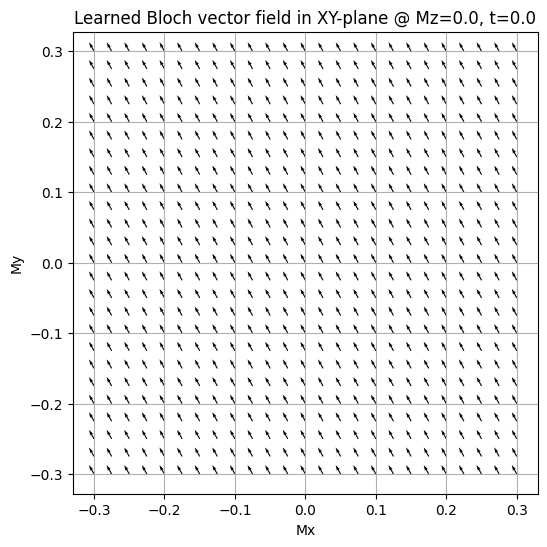

In [ ]:
# -------------------------------
# Realistic-ish Bloch parameters
# -------------------------------

# Tissue parameters: white matter @ 3T (order-of-magnitude realistic)
T1 = 1.0          # seconds   (≈ 1000 ms)
T2 = 0.08         # seconds   (≈ 80 ms)

# Off-resonance: e.g. +50 Hz (B0 inhomogeneity / chemical shift)
delta_f = 50.0    # Hz
delta_omega = 2 * torch.pi * delta_f  # rad/s

# Scaling for RF and gradients (leave at 1.0 unless your dataset uses something else)
B1_scale = 1.0
G_scale  = 1.0

p_example = torch.tensor(
    [T1, T2, delta_omega, B1_scale, G_scale],
    device=device,
    dtype=torch.float32,
)

# RF and gradient controls
# Assume units are "normalized" controls that your network saw during training.
# Here: small B1 along +x, mild readout gradient along x, zero along y.
B1x = 0.002   # small transverse RF amplitude
B1y = 0.0
Gx  = 0.01    # mild gradient
Gy  = 0.0

u_example = torch.tensor(
    [B1x, B1y, Gx, Gy],
    device=device,
    dtype=torch.float32,
)

# --------------------------------------
# Plot the learned Bloch vector field
# --------------------------------------
plot_bloch_vector_field_xy(
    model=model,
    device=device,
    u=u_example,
    p=p_example,
    Mz=0.0,   # transverse plane
    r=0.3,
    n=25,
    t0=0.0,
    normalize=False,
)
#Not that useful because vector field does not learn dynamics outside of test cases 


In [87]:
# Plot trajectories in 3D
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

@torch.no_grad()
def plot_vector_field_along_trajectory(
    model,
    device,
    batch,
    t_shared,
    traj_idx: int = 0,
    step: int = 2,
    t_offset: float = 0.0,
):
    """
    Plot dM/dt as arrows along a *real* trajectory M(t) from the dataset.

    Args:
        model    : trained Neural ODE model with .dynamics(t, M, u, p)
        device   : torch.device
        batch    : one batch from your DataLoader (dict with 'y','u','p')
        t_shared : 1D tensor of times, shape (T,)
        traj_idx : which trajectory in the batch to plot (0 <= traj_idx < B)
        step     : subsample factor along time (plot every 'step'-th point)
        t_offset : optional time offset if your internal t is not exactly t_shared
    """
    model.eval()

    # Extract data for this trajectory
    y = batch["y"].to(device)    # (B,T,3)
    u = batch["u"].to(device)    # (B,T,4)
    p = batch["p"].to(device)    # (B,5)

    M_traj = y[traj_idx]         # (T,3)
    u_traj = u[traj_idx]         # (T,4)
    p_traj = p[traj_idx]         # (5,)
    T = M_traj.shape[0]

    # Subsample times to avoid too many arrows
    idx = torch.arange(0, T, step, device=device)
    M_sub = M_traj[idx]          # (N,3)
    u_sub = u_traj[idx]          # (N,4)
    t_sub = t_shared[idx].to(device) + t_offset  # (N,)

    # Repeat p for each time
    p_sub = p_traj.unsqueeze(0).expand(M_sub.shape[0], -1)  # (N,5)

    # Compute dM/dt at each sampled point
    dMdt_list = []
    for k in range(M_sub.shape[0]):
        t_k = t_sub[k]
        M_k = M_sub[k].unsqueeze(0)      # (1,3)
        u_k = u_sub[k].unsqueeze(0)      # (1,4)
        p_k = p_sub[k].unsqueeze(0)      # (1,5)
        dMdt_k = model.dynamics(t_k, M_k, u_k, p_k)  # (1,3)
        dMdt_list.append(dMdt_k.squeeze(0))
    dMdt = torch.stack(dMdt_list, dim=0).cpu().numpy()  # (N,3)

    M_sub_np = M_sub.cpu().numpy()
    Mx, My, Mz = M_sub_np[:,0], M_sub_np[:,1], M_sub_np[:,2]
    dMx, dMy, dMz = dMdt[:,0], dMdt[:,1], dMdt[:,2]

    # --- 3D quiver along trajectory ---
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Plot the trajectory itself
    ax.plot(Mx, My, Mz, "-o", markersize=3, label="M(t) trajectory")

    # Plot local vector field (dM/dt) at those points
    d_max = np.max(np.linalg.norm(dMdt, axis=1))
    scale = 0.1 / d_max  # shrink arrows

    ax.quiver(Mx, My, Mz, 
              dMx * scale, dMy * scale, dMz * scale,
              length=1.0, normalize=False)
    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Local vector field along trajectory #{traj_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()


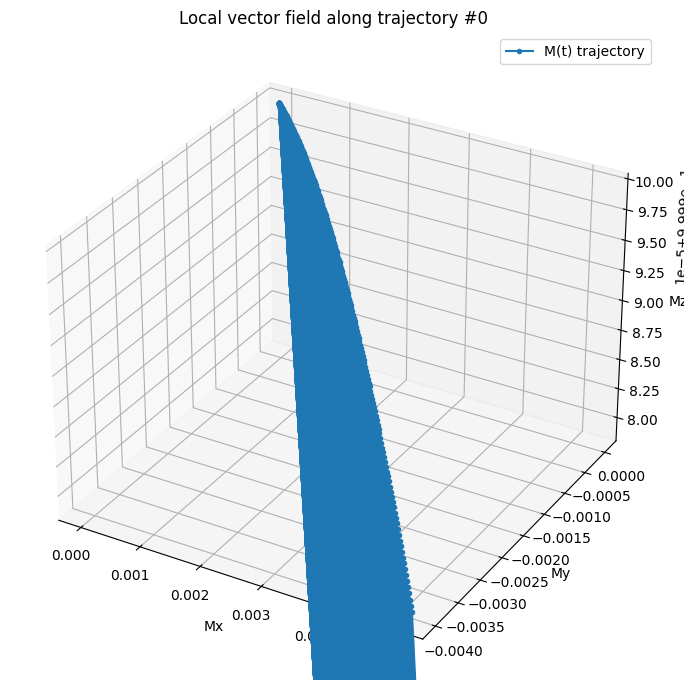

In [88]:
# Get one batch from your DataLoader
batch = next(iter(train_loader))  # or val_loader

plot_vector_field_along_trajectory(
    model=model,
    device=device,
    batch=batch,
    t_shared=t_shared,  # same as used in training
    traj_idx=0,         # pick which trajectory in the batch
    step=2,             # plot every 2nd time step
)


In [92]:
import torch
import numpy as np

model.eval()
device = DEVICE

batch = next(iter(train_loader))
y  = batch["y"].to(device)   # (B,T,3)
u  = batch["u"].to(device)   # (B,T,4)
p  = batch["p"].to(device)   # (B,5)
t  = t_shared.to(device)     # (T,)

B, T, _ = y.shape

# ---- finite-difference dy/dt from data ----
dt = (t[1:] - t[:-1]).mean().item()
dy_dt_fd = (y[:,1:,:] - y[:,:-1,:]) / dt        # (B, T-1, 3)

# ---- model-based derivative at same states ----
with torch.no_grad():
    dM_model_list = []
    for k in range(T-1):
        t_k = t[k]
        M_k = y[:,k,:]          # (B,3)
        u_k = u[:,k,:]          # (B,4)
        p_k = p                 # (B,5) same p for all time in that traj batch

        dM_k = model.dynamics(t_k, M_k, u_k, p_k)   # (B,3)
        dM_model_list.append(dM_k)

    dM_model = torch.stack(dM_model_list, dim=1)    # (B, T-1, 3)

err = (dM_model - dy_dt_fd).cpu().numpy()
mse_deriv  = np.mean(err**2)
rmse_deriv = np.sqrt(mse_deriv)

print("Derivative MSE:", mse_deriv)
print("Derivative RMSE:", rmse_deriv)

# per-component
mse_comp  = np.mean(err**2, axis=(0,1))
rmse_comp = np.sqrt(mse_comp)
print("Per-component derivative RMSE [Mx, My, Mz]:", rmse_comp)



Derivative MSE: 28.263412
Derivative RMSE: 5.3163347
Per-component derivative RMSE [Mx, My, Mz]: [6.8299217  6.1708336  0.24663053]


In [93]:
# assuming you still have dy_dt_fd and dM_model from before
dy = dy_dt_fd.cpu().numpy()

true_mse  = np.mean(dy**2)
true_rmse = np.sqrt(true_mse)

rel_rmse  = rmse_deriv / (true_rmse + 1e-8)

print("True derivative RMSE:", true_rmse)
print("Relative RMSE (model / true):", rel_rmse)


True derivative RMSE: 11.260305
Relative RMSE (model / true): 0.4721306


In [95]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

@torch.no_grad()
def plot_vector_field_on_shell(model, device, loader, t_shared, 
                               num_traj=10, t_idx=100, subsample=5):
    """
    Plot dM/dt on a shell of states taken from real data,
    normalized so it looks like a Bloch sphere.
    """
    model.eval()
    batch = next(iter(loader))
    y = batch["y"].to(device)   # (B,T,3)
    u = batch["u"].to(device)   # (B,T,4)
    p = batch["p"].to(device)   # (B,5)
    t = t_shared.to(device)

    B, T, _ = y.shape
    num_traj = min(num_traj, B)
    t_idx = min(t_idx, T-1)

    # Take a slice across several trajectories at fixed time
    M = y[:num_traj, t_idx, :]          # (num_traj, 3)
    u_slice = u[:num_traj, t_idx, :]    # (num_traj, 4)
    p_slice = p[:num_traj, :]           # (num_traj, 5)
    t0 = t[t_idx]

    # Optionally jitter around those points to get a "shell"
    jitter = 0.02 * M.norm(dim=-1, keepdim=True)
    M = M + torch.randn_like(M) * jitter

    # Normalize for plotting so points lie near unit sphere
    M_norm = M.norm(dim=-1, keepdim=True) + 1e-8
    M_plot = M / M_norm

    dMdt = model.dynamics(t0, M, u_slice, p_slice)   # (num_traj,3)

    # Scale arrows so they fit nicely
    d = dMdt.cpu().numpy()
    d_norm = np.linalg.norm(d, axis=1, keepdims=True) + 1e-8
    d_unit = d / d_norm
    arrow_scale = 0.2
    d_plot = d_unit * arrow_scale

    M_np = M_plot.cpu().numpy()
    Mx, My, Mz = M_np[:,0], M_np[:,1], M_np[:,2]
    dMx, dMy, dMz = d_plot[:,0], d_plot[:,1], d_plot[:,2]

    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection="3d")

    # Draw unit sphere wireframe for context
    u_s = np.linspace(0, 2*np.pi, 40)
    v_s = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u_s), np.sin(v_s))
    ys = np.outer(np.sin(u_s), np.sin(v_s))
    zs = np.outer(np.ones_like(u_s), np.cos(v_s))
    ax.plot_wireframe(xs, ys, zs, color="lightgray", linewidth=0.3, alpha=0.5)

    # Plot points and arrows
    ax.scatter(Mx, My, Mz, s=20, label="states (normalized)")
    ax.quiver(Mx, My, Mz, dMx, dMy, dMz, length=1.0, normalize=False, color="red")

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Learned vector field on normalized shell at t index {t_idx}")
    ax.set_box_aspect([1,1,1])
    plt.legend()
    plt.show()


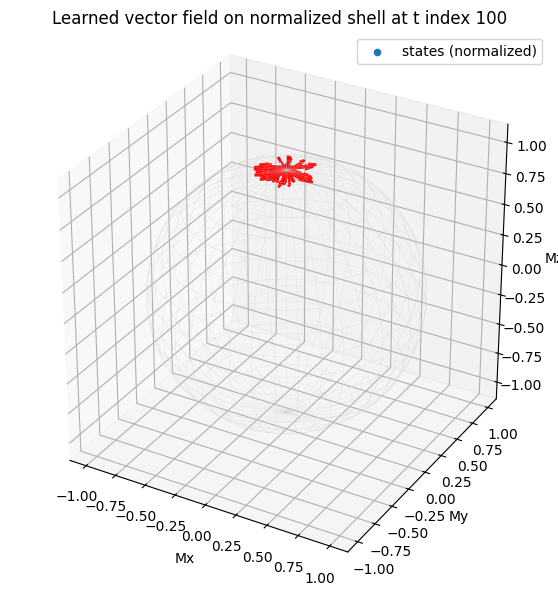

In [96]:
plot_vector_field_on_shell(
    model, DEVICE, train_loader, t_shared,
    num_traj=50, t_idx=100, subsample=1
)


In [97]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation

def animate_bloch_trajectory(model, device, loader, t_shared, traj_idx=0, save=None):
    model.eval()

    batch = next(iter(loader))
    y  = batch["y"].to(device)   # (B,T,3)
    u  = batch["u"].to(device)   # (B,T,4)
    p  = batch["p"].to(device)
    t  = t_shared.to(device)

    M = y[traj_idx]     # (T,3)
    u_traj = u[traj_idx]
    p_traj = p[traj_idx].unsqueeze(0)

    # normalize for visualization (no physical change)
    M_plot = M / (M.norm(dim=1, keepdim=True) + 1e-8)
    M_np = M_plot.cpu().numpy()
    Mx, My, Mz = M_np[:,0], M_np[:,1], M_np[:,2]

    # --- set up 3D plot ---
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # draw sphere
    u_s = np.linspace(0, 2*np.pi, 40)
    v_s = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u_s), np.sin(v_s))
    ys = np.outer(np.sin(u_s), np.sin(v_s))
    zs = np.outer(np.ones_like(u_s), np.cos(v_s))
    ax.plot_wireframe(xs, ys, zs, color="lightgray", alpha=0.3, linewidth=0.3)

    point, = ax.plot([], [], [], 'bo', markersize=8)
    arrow = ax.quiver(0,0,0,0,0,0)

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_title("Neural ODE Bloch trajectory")

    # --- animation function ---
    def update(k):
        nonlocal arrow

        # point location
        M_k = M_plot[k].unsqueeze(0)
        u_k = u_traj[k].unsqueeze(0)
        t_k = t[k]

        # compute derivative
        dMdt = model.dynamics(t_k, M[k].unsqueeze(0), u_k, p_traj)[0]
        dMdt_np = (dMdt / (dMdt.norm() + 1e-8)).cpu().numpy() * 0.2  # scaled

        # update point
        point.set_data([Mx[k]], [My[k]])
        point.set_3d_properties([Mz[k]])

        # update arrow (remove old one)
        arrow.remove()
        arrow = ax.quiver(
            Mx[k], My[k], Mz[k],
            dMdt_np[0], dMdt_np[1], dMdt_np[2],
            color='red', length=1.0, normalize=False
        )

        return point, arrow

    anim = animation.FuncAnimation(fig, update, frames=len(M), interval=50, blit=False)

    if save:
        anim.save(save, writer='ffmpeg', fps=20)
        print("Saved animation to", save)

    plt.show()

    return anim


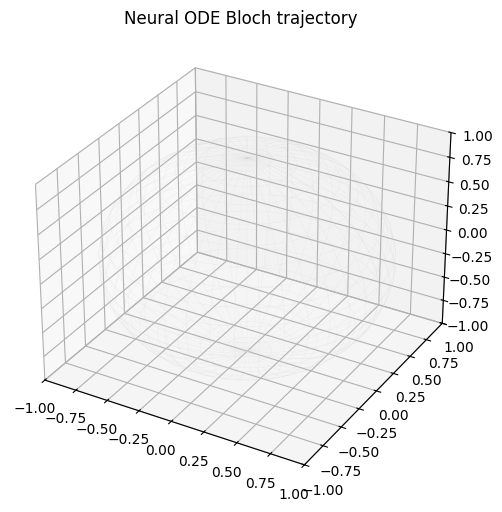

In [98]:
animate_bloch_trajectory(model, DEVICE, train_loader, t_shared, traj_idx=0)


In [100]:
batch = next(iter(train_loader))
y = batch["y"]      # (B,T,3)
t = t_shared        # (T,)

traj_idx = 0
M = y[traj_idx]     # (T,3)

print("M[0]:", M[0])
print("M[-1]:", M[-1])

delta = M - M[0]
print("Max |ΔMx|, |ΔMy|, |ΔMz| over time:", delta.abs().max(dim=0).values)

print("Mx range:", M[:,0].min().item(), "→", M[:,0].max().item())
print("My range:", M[:,1].min().item(), "→", M[:,1].max().item())
print("Mz range:", M[:,2].min().item(), "→", M[:,2].max().item())


M[0]: tensor([7.4350e-05, 4.2479e-06, 1.0000e+00])
M[-1]: tensor([0.0370, 0.0014, 0.9993])
Max |ΔMx|, |ΔMy|, |ΔMz| over time: tensor([0.0369, 0.0014, 0.0007])
Mx range: 7.435044244630262e-05 → 0.03700519725680351
My range: 4.2478541217860766e-06 → 0.0013911585556343198
Mz range: 0.9992887377738953 → 1.0


In [101]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation

def animate_raw_trajectory(model, device, loader, t_shared, traj_idx=0, save=None):
    model.eval()

    batch = next(iter(loader))
    y  = batch["y"].to(device)   # (B,T,3)
    u  = batch["u"].to(device)   # (B,T,4)
    p  = batch["p"].to(device)
    t  = t_shared.to(device)

    M = y[traj_idx]              # (T,3)
    M_np = M.cpu().numpy()
    Mx, My, Mz = M_np[:,0], M_np[:,1], M_np[:,2]

    # --- set up 3D plot ---
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # full trajectory line
    ax.plot(Mx, My, Mz, "-k", linewidth=1, alpha=0.6)

    # point that will move
    point, = ax.plot([], [], [], 'bo', markersize=6)

    # axis limits with a small margin
    margin = 0.05
    ax.set_xlim(Mx.min()-margin, Mx.max()+margin)
    ax.set_ylim(My.min()-margin, My.max()+margin)
    ax.set_zlim(Mz.min()-margin, Mz.max()+margin)

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Raw magnetization trajectory #{traj_idx}")

    def update(k):
        point.set_data([Mx[k]], [My[k]])
        point.set_3d_properties([Mz[k]])
        return point,

    anim = animation.FuncAnimation(fig, update, frames=len(M), interval=50, blit=True)

    if save is not None:
        anim.save(save, writer="ffmpeg", fps=20)
        print("Saved animation to", save)

    plt.show()
    return anim


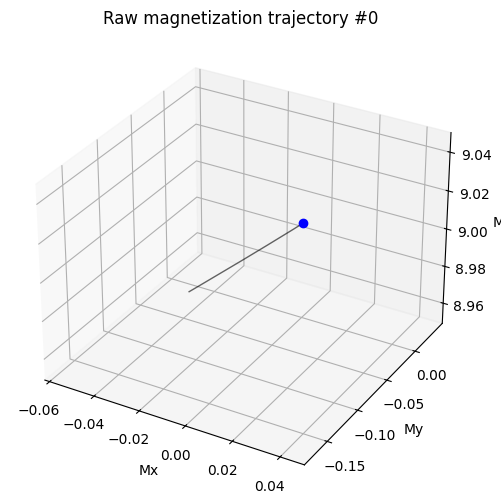

In [102]:
animate_raw_trajectory(model, DEVICE, train_loader, t_shared, traj_idx=0)


In [103]:
import numpy as np
import torch

batch = next(iter(train_loader))
y = batch["y"]  # (B,T,3)

# ranges over time for each trajectory
delta = y - y[:, :1, :]        # y - initial
max_delta = delta.abs().max(dim=1).values  # (B,3)

print("Mean max ΔM over time [Mx,My,Mz]:", max_delta.mean(dim=0))
print("95th percentile max ΔM:", torch.quantile(max_delta, 0.95, dim=0))

# also check norms
M_norm = y.norm(dim=-1)
print("Norm range in this batch:", M_norm.min().item(), "→", M_norm.max().item())


Mean max ΔM over time [Mx,My,Mz]: tensor([0.0734, 0.0619, 0.0015])
95th percentile max ΔM: tensor([0.3680, 0.3285, 0.0072])
Norm range in this batch: 0.9998916983604431 → 16.0


In [104]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load full training NPZ
train_npz = np.load(TRAIN_NPZ)
y_all = train_npz["y"]   # (N,T,3)
t_np  = train_npz["t"]   # (T,) or (N,T)

N, T, _ = y_all.shape

# Compute max |ΔM| for each trajectory over time
delta_all = y_all - y_all[:, :1, :]            # (N,T,3)
max_delta_all = np.abs(delta_all).max(axis=1)  # (N,3) max over time
mag_delta = np.linalg.norm(max_delta_all, axis=1)  # (N,)

# Sort trajectories by magnitude of motion (descending)
idx_sorted = np.argsort(-mag_delta)
top10_idx = idx_sorted[:10]

print("Top 10 most dynamic trajectory indices:", top10_idx)
print("Their max ΔM (Mx,My,Mz):")
print(max_delta_all[top10_idx])


Top 10 most dynamic trajectory indices: [2287 2303 1392   78 3533 3495 2151 2537 1493  850]
Their max ΔM (Mx,My,Mz):
[[0.89399517 0.18666992 0.0271759 ]
 [0.61522365 0.6116339  0.02408504]
 [0.79826033 0.32510248 0.02455044]
 [0.05766245 0.84984773 0.0250349 ]
 [0.29034513 0.7379481  0.022295  ]
 [0.48541543 0.61617184 0.02260017]
 [0.75636727 0.18273792 0.01936531]
 [0.75011134 0.18910952 0.02099991]
 [0.43438303 0.6334822  0.02018166]
 [0.72688186 0.24322075 0.02005768]]


In [105]:
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # noqa

def animate_npz_trajectory(y_all, t_np, traj_idx, save=None):
    """
    Animate a single trajectory from the NPZ file.
    Shows the true magnetization path in 3D with a moving point.
    """
    M = y_all[traj_idx]      # (T,3)
    Mx, My, Mz = M[:,0], M[:,1], M[:,2]
    T_len = M.shape[0]

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # Plot full path
    ax.plot(Mx, My, Mz, "-k", linewidth=1, alpha=0.6)

    # Moving point
    point, = ax.plot([], [], [], "bo", markersize=6)

    # Set axis limits with a bit of margin
    margin = 0.05 * max(
        max(Mx.max()-Mx.min(), 1e-3),
        max(My.max()-My.min(), 1e-3),
        max(Mz.max()-Mz.min(), 1e-3),
    )
    ax.set_xlim(Mx.min()-margin, Mx.max()+margin)
    ax.set_ylim(My.min()-margin, My.max()+margin)
    ax.set_zlim(Mz.min()-margin, Mz.max()+margin)

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"True magnetization trajectory #{traj_idx}")

    def update(frame):
        point.set_data([Mx[frame]], [My[frame]])
        point.set_3d_properties([Mz[frame]])
        return point,

    anim = animation.FuncAnimation(
        fig, update, frames=T_len,
        interval=50, blit=True
    )

    if save is not None:
        anim.save(save, writer="ffmpeg", fps=20)
        print("Saved animation to", save)

    plt.show()
    return anim


Animating trajectory 2287 (rank 1)


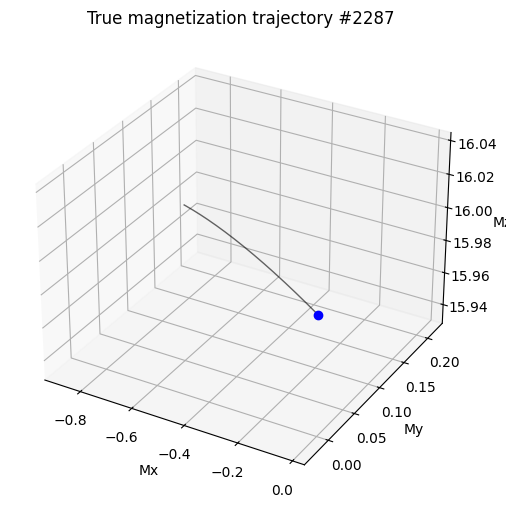

Animating trajectory 2303 (rank 2)


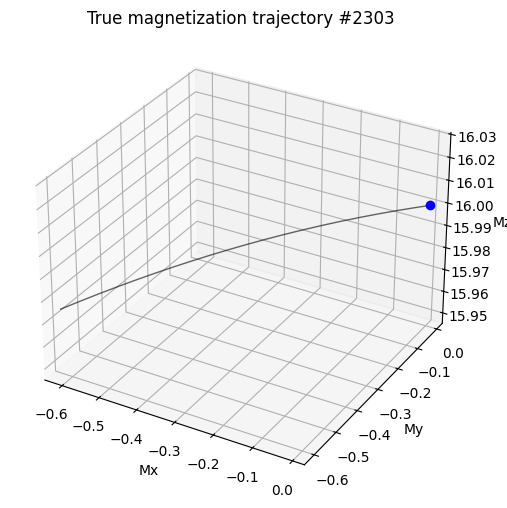

Animating trajectory 1392 (rank 3)


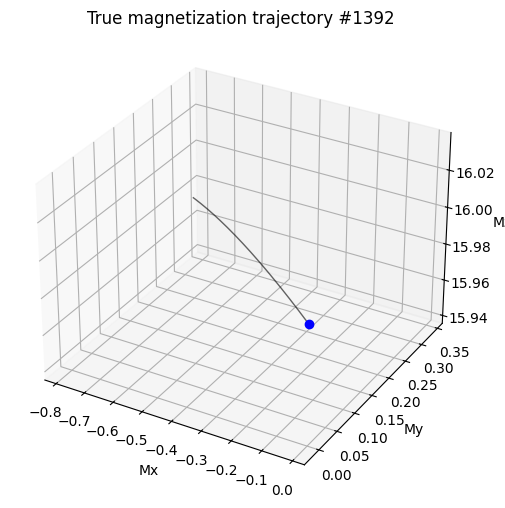

Animating trajectory 78 (rank 4)


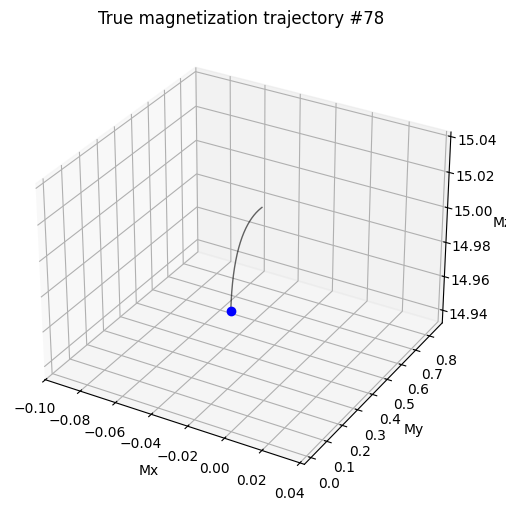

Animating trajectory 3533 (rank 5)


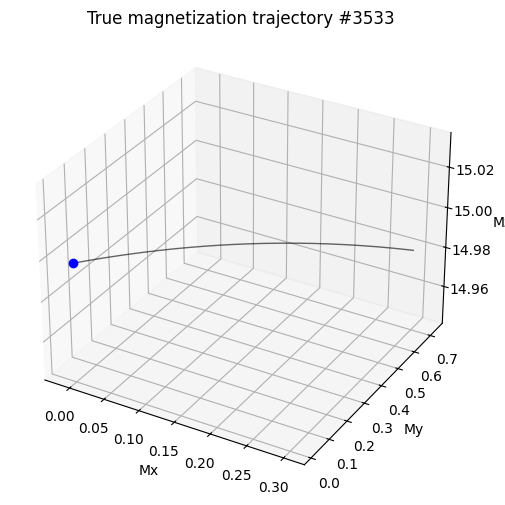

Animating trajectory 3495 (rank 6)


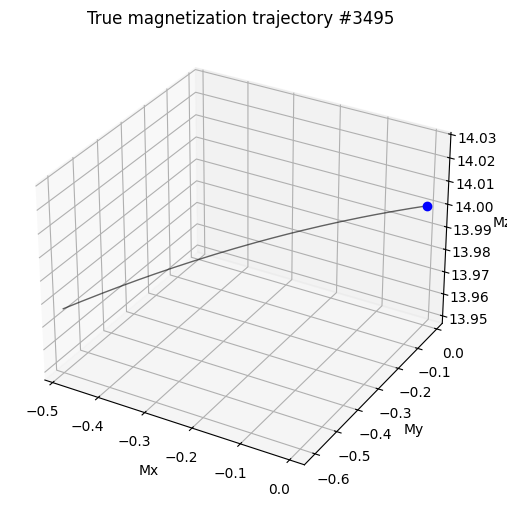

Animating trajectory 2151 (rank 7)


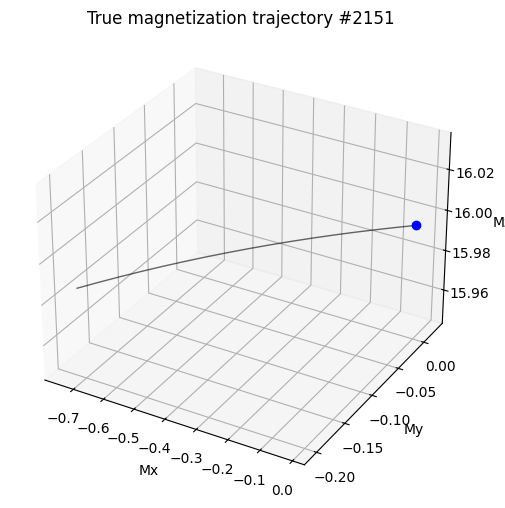

Animating trajectory 2537 (rank 8)


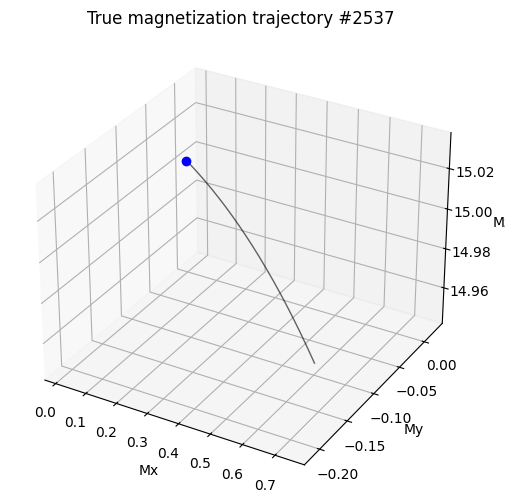

Animating trajectory 1493 (rank 9)


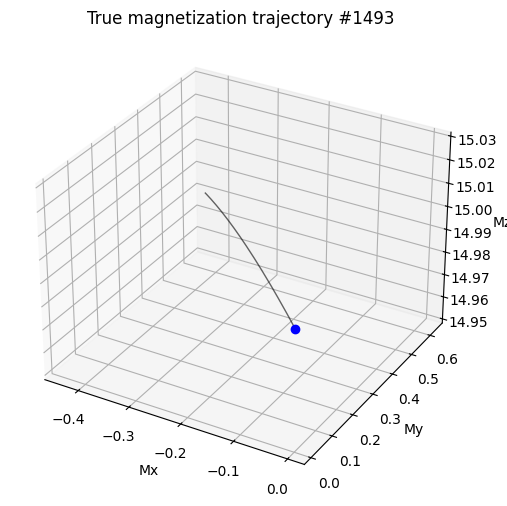

Animating trajectory 850 (rank 10)


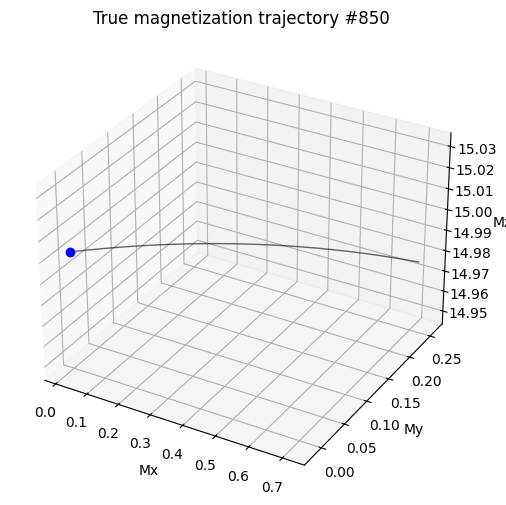

In [106]:
# Example: animate all top 10 one by one
for i, idx in enumerate(top10_idx):
    print(f"Animating trajectory {idx} (rank {i+1})")
    animate_npz_trajectory(y_all, t_np, traj_idx=idx)
    # or save to file:
    # animate_npz_trajectory(y_all, t_np, traj_idx=idx, save=f"traj_{idx}.mp4")
